# Box Office Intelligence: EDA for a New Movie Studio
### Exploratory Data Analysis Report — New Movie Studio Initiative
----------



# 1. Business Understanding

### 1.1 Overview

The company plans to enter the film industry by launching a new movie studio.<br>
However, it currently lacks experience in film production and does not have a clear strategy <br>
for selecting the types of movies to produce.Given the high costs and risks associated with movie production,<br>
 it is critical to make data-driven decisions to increase the likelihood of box office success.

### 1.2 Problem Statement

The company does not know which types of films are most successful at the box office or which <br>
characteristics (e.g., genre, budget, release timing) contribute to higher profitability. <br>
Without this knowledge, the studio risks investing in films that may not generate sufficient returns.

### 1.3 Objective

The objective of this analysis is to explore historical movie data to identify the key drivers of<br>
box office performance. This includes analyzing how genre, budget, and other film attributes influence <br>
revenue, return on investment (ROI), and profitability. The goal is to translate these insights into <br>
a practical strategy that the studio can use to guide its film production decisions.

Specifically, the analysis aims to:<br>

- Identify which movie genres generate the highest box office revenue<br>
- Evaluate profitability using return on investment (ROI)<br>
- Evaluate impact of critical reception on box office
- Analyze the relationship between production budget and revenue<br>
- Distinguish between consistently profitable and high-risk film types<br>
- Provide a data-driven strategy to guide film production decisions<br>

### 1.4 Success Metrics

To evaluate film performance and support decision-making, the following metrics are used:

- Worldwide Gross Revenue: Measures total box office performance
- Production Budget: Represents the cost of producing a film
- Profit: Calculated as worldwide gross minus production budget
- Return on Investment (ROI): Measures efficiency of investment
- Profitability Rate: Percentage of films that generate profit

These metrics allow for a balanced evaluation of both revenue generation and financial efficiency, <br>
ensuring that recommendations are not based solely on high earnings but also on sustainable profitability.

### 1.5 Constraints

This analysis is subject to several limitations:
- Data Quality Issues: Missing values, inconsistent formatting, and potential inaccuracies in reported budgets and revenues
- Dataset Coverage: The available data may not include all films or fully represent the entire industry
- Genre Classification: Some films belong to multiple genres, which may affect analysis accuracy
- External Factors Not Included: Variables such as marketing spend, competition, and audience sentiment are not captured
- Outliers: Extremely high-grossing films (blockbusters) may skew results

Despite these constraints, the analysis provides meaningful insights that can guide strategic decision-making for the new movie studio.

<br>
<br>
<br>

| Item | Detail |
|------|--------|
| **Datasets** | Box Office Mojo · The Numbers · RT Movie Info · RT Reviews |
| **Coverage** | 2010–2018 theatrical releases |
| **Tools** | Python · pandas · NumPy · Seaborn · Matplotlib · SciPy |
| **Chart types** | Line · Scatter · KDE · Lollipop · Log-log scatter · Dual-axis |




-------
# 2. Data Understanding

This analysis uses multiple datasets containing information on movie performance, financials, and attributes.<br>
The datasets are combined to provide a comprehensive view of box office performance and the factors that influence it.<br>
The primary focus is on understanding how film characteristics such as genre, production budget, and release details relate to revenue and profitability.

### 2.1 Data Sources

The analysis draws from the following key datasets:

- **Box Office Mojo (BOM) dataset**
Contains information on movie titles, studios, domestic and foreign gross revenue, and release year.<br>
→ Used to analyze overall box office performance

- **The Numbers (TN) dataset**
Includes production budgets and worldwide gross revenue<br>
→ Used to calculate profitability and return on investment (ROI)

- **Rotten Tomatoes (RT) dataset**
Provides movie metadata such as genre, ratings, runtime, and release dates<br>
→ Used to categorize films and enrich analysis


### 2.2 Imports & Global Seaborn Theme

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings, ast
warnings.filterwarnings('ignore')





### 2.3 Load and Audit All Datasets

Load every file and run a full audit before touching the data. Document all quality issues.

| Dataset | Key Issue Found |
|---------|----------------|
| BOM | `foreign_gross` missing 39.8% of values; stored as mixed string/float |
| TN | All money columns stored as `'$1,234,567'` strings — need parsing |
| RT Info | `genre` is pipe-delimited (`'Action\|Drama'`); `box_office` missing 78% |
| RT Reviews | Special characters require `encoding='latin-1'` |



In [18]:
#Load all five datasets 
bom    = pd.read_csv('original_data/bom.movie_gross.csv')
tn     = pd.read_csv('original_data/tn.movie_budgets.csv')
rt_inf = pd.read_csv('original_data/rt.movie_info.tsv', sep='\t', encoding='latin-1')
rt_rev = pd.read_csv('original_data/rt.reviews.tsv', sep='\t', encoding='latin-1')

datasets = {'BOM': bom, 'TN': tn, 'RT_INFO': rt_inf, 'RT_REV': rt_rev}



### 2.4 Sample Rows — Quick Sanity Check  

A preview of the dataset is examined to ensure that the data has been correctly loaded.<br>
This helps in verifing column names, data types, and overall structure before proceeding with further analysis.

In [19]:
print('BOM');    display(bom.head(3))
print('TN');     display(tn.head(3))
print('RT INFO'); display(rt_inf[['id','genre','rating','box_office','runtime']].head(3))
print('RT REV');  display(rt_rev[['id','fresh','rating','critic']].head(3))


BOM


,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010


TN


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"


RT INFO


,id,genre,rating,box_office,runtime
0,1,Action and Adventure|Classics|Drama,R,NaN,104 minutes
1,3,Drama|Science Fiction and Fantasy,R,"600,000",108 minutes
2,5,Drama|Musical and Performing Arts,R,NaN,116 minutes


RT REV


,id,fresh,rating,critic
0,3,fresh,3/5,PJ Nabarro
1,3,rotten,NaN,Annalee Newitz
2,3,fresh,NaN,Sean Axmaker


# 3. Data Preparation  

### 3.1 Overview  
The data preparation phase focused on resolving data quality issues identified during the audit and transforming <br>
the datasets into a clean, analysis-ready format. Key operations included cleaning financial data, handling missing <br>
values, restructuring categorical variables, and engineering new features to support profitability analysis.  


### 3.2 Data Cleaning  

Several cleaning steps were performed to address inconsistencies and ensure proper formatting:  

#### *Currency Conversion* 
Financial columns in the TN dataset (`production_budget`, `domestic_gross`, `worldwide_gross`) were originally stored as<br>
strings containing symbols such as `$` and `,`. These symbols were removed, and the columns were converted to numeric (`float`)<br> 
format to enable accurate calculations.  

#### *Handling Missing Values*
Missing values were identified and handled appropriately:  

- Missing values in the `foreign_gross` column (BOM dataset) were replaced with `0` to retain records while acknowledging no reported international revenue  
- Rows with missing or invalid key financial values were reviewed and filtered where necessary  

#### *Filtering Invalid Data* 
To ensure meaningful analysis:  

- Observations with zero or unrealistic values in `production_budget` or `worldwide_gross` were removed  
- This step was necessary to avoid distortions in ROI and profitability calculations  


### 3.3 Data Transformation  

#### *Genre Processing (RT Dataset)*  
The `genre` column in the Rotten Tomatoes dataset contained multiple genres separated by pipe (`|`) characters.  

- These values were exploded so that each genre appears in its own row  
- This allows for accurate genre-level aggregation and analysis  


### 3.4 Feature Engineering  

New variables were created to support deeper financial analysis:  

- **Return on Investment (ROI):**  
  `ROI = worldwide_gross / production_budget`  

- **Profitability Indicator:**  
  `profitable = worldwide_gross > production_budget`  

These features allow for evaluation beyond raw revenue, focusing on efficiency and financial success.  


### 3.5 Final Dataset  

The final prepared dataset includes:  

- Cleaned and standardized financial variables  
- Completed revenue fields with handled missing values  
- Expanded genre data for detailed analysis  
- Engineered profitability metrics (ROI and profitability)  

This dataset provides a reliable foundation for exploratory data analysis and supports accurate, data-driven business recommendations.  

In [20]:
# BOM: fix types, fill missing, compute total gross

# Convert 'foreign_gross' to numeric (handle errors by setting invalid values to NaN)
# Then fill missing values with 0 (assumes no reported foreign revenue)
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce').fillna(0)

# Convert 'domestic_gross' to numeric (invalid values become NaN)
bom['domestic_gross'] = pd.to_numeric(bom['domestic_gross'], errors='coerce')

# Drop rows where 'domestic_gross' is missing since it's a key revenue metric
bom = bom.dropna(subset=['domestic_gross']).copy()

# Create a new column 'total_gross' by summing domestic and foreign revenue
bom['total_gross'] = bom['domestic_gross'] + bom['foreign_gross']

# Print summary of cleaned dataset: number of rows and year range
print(f'BOM cleaned: {bom.shape[0]} rows | years {bom.year.min()}–{bom.year.max()}')

# Save the cleaned BOM dataset to a CSV file for future use
bom.to_csv("cleaned_data/cleaned_bom_movie_gross.csv", index=False)

BOM cleaned: 3359 rows | years 2010–2018


In [21]:
# TN: strip currency strings, engineer ROI features

# Loop through monetary columns and clean them
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    # Remove currency symbols ($) and commas, then convert to float
    tn[col] = tn[col].str.replace(r'[\$,]', '', regex=True).astype(float)

# Filter out rows with invalid financial data (zero or negative values)
# Ensures meaningful ROI and profitability calculations
tn = tn[(tn['production_budget'] > 0) & (tn['worldwide_gross'] > 0)].copy()

# Create Return on Investment (ROI): measures how much revenue is generated per dollar spent
tn['roi'] = tn['worldwide_gross'] / tn['production_budget']

# Create profitability flag: True if the movie made more than its budget
tn['profitable'] = tn['worldwide_gross'] > tn['production_budget']

# Scale financial values to millions for easier interpretation and visualization
tn['budget_m'] = tn['production_budget'] / 1e6
tn['ww_m']     = tn['worldwide_gross']   / 1e6

# Print summary statistics for quick validation
print(f'TN cleaned: {tn.shape[0]} rows')

# Display ROI range (excluding extreme outliers using 1st–99th percentiles)
print(f'ROI range (1st–99th pct): {tn.roi.quantile(.01):.2f}x – {tn.roi.quantile(.99):.1f}x')

# Show profitability count and percentage
print(f'Profitable: {tn.profitable.sum()} / {len(tn)} ({tn.profitable.mean()*100:.1f}%)')

# Save cleaned dataset
tn.to_csv("cleaned_data/cleaned_tn_movie_budgets.csv", index=False)

TN cleaned: 5415 rows
ROI range (1st–99th pct): 0.00x – 55.7x
Profitable: 3657 / 5415 (67.5%)


In [22]:
# ── RT Info: clean box office + explode genres ───────────

# Convert 'box_office' to numeric by removing currency symbols and commas
# Invalid values are coerced to NaN
rt_inf['bo'] = pd.to_numeric(
    rt_inf['box_office'].str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

# Process genre column:
# - Fill missing genres with 'Unknown'
# - Split multiple genres separated by '|'
# - Explode into separate rows (one row per genre per film)
rt_genre = (
    rt_inf
    .assign(genre=rt_inf['genre'].fillna('Unknown').str.split('|'))
    .explode('genre')
    .copy()
)

# Clean genre values by removing extra whitespace
rt_genre['genre'] = rt_genre['genre'].str.strip()

# Print summary of transformation:
# - Original number of films vs expanded genre rows
# - Number of unique genres
# - Number of films with valid box office data
print(f'RT Info: {rt_inf.shape[0]} films → {rt_genre.shape[0]} genre rows after explode')
print(f'Genres found: {rt_genre.genre.nunique()}')
print(f'Films with box office data: {rt_inf.bo.notna().sum()}')

# Save cleaned RT dataset
rt_genre.to_csv("cleaned_data/cleaned_rt_movie_info.csv", index=False)

RT Info: 1560 films → 3581 genre rows after explode
Genres found: 22
Films with box office data: 340


In [23]:
# RT Reviews: filter to valid labels, compute fresh % 

# Filter dataset to keep only valid review labels ('fresh' or 'rotten')
# Removes any invalid or missing labels to ensure accurate scoring
rt_rev_clean = rt_rev[rt_rev['fresh'].isin(['fresh', 'rotten'])].copy()

# Compute Rotten Tomatoes score per film
rt_scores = (
    rt_rev_clean
    .groupby('id')  # Group reviews by movie ID
    .agg(
        # Calculate percentage of 'fresh' reviews (converted to %)
        fresh_pct=('fresh', lambda s: (s == 'fresh').mean() * 100),
        
        # Count total number of reviews per film
        n_reviews=('fresh', 'size')
    )
    .reset_index()
)

# Print summary statistics for validation
print(f'RT Scores: {rt_scores.shape[0]} films scored')

# Average critic score across all films
print(f'Avg fresh %: {rt_scores.fresh_pct.mean():.1f}%')

# Median number of reviews per film (helps understand coverage)
print(f'Reviews per film (median): {rt_scores.n_reviews.median():.0f}')

# Save cleaned RT review scores dataset
rt_scores.to_csv("cleaned_data/cleaned_rt_reviews.csv", index=False)

RT Scores: 1135 films scored
Avg fresh %: 57.7%
Reviews per film (median): 23


### Cleaning Summary

| Dataset | Before | After | Key Change |
|---------|--------|-------|------------|
| BOM | 3,387 rows | 3,359 rows | Dropped 28 null domestic_gross; filled 1,350 foreign_gross with 0 |
| TN | 5,782 rows | 5,415 rows | Dropped zero-budget/zero-gross; added roi + profitable columns |
| RT Info | 1,560 rows | 3,581 genre rows | Exploded pipe-delimited genres |
| RT Reviews | 54,432 rows | 1,135 films scored | Aggregated to fresh_pct per film |



## 4. Modeling and Evaluation  

###  4.1 Overview  
In this stage, analytical techniques are applied to identify patterns and relationships in the data that explain movie success.<br>
The analysis focuses on using exploratory data analysis (EDA) and engineered features such as ROI and profitability to <br>
evaluate film performance and support business decisions.  


### 4.2 Analytical Approach  
The analysis examines how key variables influence box office success, including:  

- Production budget  
- Worldwide gross revenue  
- Genre  
- Return on Investment (ROI)  
- Profitability  

These relationships are explored using visualizations such as scatter plots and trend analysis to uncover patterns in the data.  


### 4.3 Evaluation of Findings  
The results are evaluated based on their ability to answer the core business questions:  

- Which genres generate the highest revenue?  
- Which films deliver the strongest ROI?  
- Does higher budget lead to higher returns?  
- Which genres are consistently profitable?  

The insights are assessed in terms of:  

- Clarity and interpretability  
- Relevance to business decision-making  
- Consistency across different metrics  


### 4.4 Key Insights Evaluation  
The analysis reveals:  

- Certain genres consistently outperform others in revenue  
- High-budget films may generate high revenue but also carry higher risk  
- ROI provides a better measure of success than revenue alone  
- Some genres offer more stable and predictable returns  




## Objective 1 — Identify which movie genres generate the highest box office revenue


To determine which genres generate the most revenue, the Rotten Tomatoes (RT Info) dataset is used after<br> 
preprocessing the `genre` column (exploded into one row per genre).  

The analysis involves:

- Grouping films by **genre**  
- Calculating:
  - **Average box office revenue** (measures per-film earning potential)  
  - **Total box office revenue** (measures overall market size)  
- Filtering to include only genres with **at least 10 films** to ensure reliable comparisons  
- Ranking genres based on both **average revenue** and **total revenue**  

This dual approach ensures that both **high-performing individual films** and **large, commercially significant genres** are identified.  

### Rationale  

- **Average revenue** highlights genres that perform well on a per-film basis  
- **Total revenue** identifies genres with strong overall market demand  
- Filtering by minimum film count reduces the impact of outliers and small sample bias  

### Expected Outcome  

This analysis helps identify genres that offer:  

- High revenue potential  
- Strong audience demand  
- Scalable opportunities for a new studio  

These insights will directly inform **genre selection strategy** for future film production.

In [24]:
# ── Genre aggregation: revenue statistics by genre ─────────────────────────

# Group data by genre and compute key revenue statistics
genre_stats = (
    rt_genre
    .groupby('genre')  # Aggregate at genre level
    .agg(
        count    = ('id',  'count'),   # Number of films per genre
        avg_bo   = ('bo',  'mean'),    # Average box office revenue
        med_bo   = ('bo',  'median'),  # Median box office (robust to outliers)
        std_bo   = ('bo',  'std'),     # Standard deviation (measures variability/risk)
        total_bo = ('bo',  'sum')      # Total revenue (market size)
    )
    
    # Filter to include only genres with sufficient sample size (>= 10 films)
    # This improves reliability and reduces noise from small samples
    .query('count >= 10')
    
    # Rank genres by average box office (per-film earning power)
    .sort_values('avg_bo', ascending=False)
    
    .reset_index()
)

# Convert values to more interpretable units
genre_stats['avg_m']   = genre_stats['avg_bo']   / 1e6   # Average revenue in millions
genre_stats['med_m']   = genre_stats['med_bo']   / 1e6   # Median revenue in millions
genre_stats['std_m']   = genre_stats['std_bo']   / 1e6   # Standard deviation in millions
genre_stats['total_b'] = genre_stats['total_bo'] / 1e9   # Total revenue in billions

# Display formatted results for easier interpretation
print('=== Genre Revenue Stats (sorted by avg box office) ===')
display(
    genre_stats[['genre','count','avg_m','med_m','total_b']]
    .rename(columns={
        'genre':'Genre',
        'count':'Films',
        'avg_m':'Avg BO ($M)',
        'med_m':'Median BO ($M)',
        'total_b':'Total BO ($B)'
    })
    .round(1)
)

=== Genre Revenue Stats (sorted by avg box office) ===


,Genre,Films,Avg BO ($M),Median BO ($M),Total BO ($B)
0,Science Fiction and Fantasy,172,80.9,33.1,2.6
1,Action and Adventure,366,62.3,35.8,4.9
2,Animation,47,56.2,42.2,1.1
3,Kids and Family,99,54.7,39.8,1.8
4,Romance,198,48.3,22.7,2.0
5,Mystery and Suspense,309,42.6,17.2,2.8
6,Comedy,550,41.9,17.4,5.7
7,Drama,912,28.3,8.7,5.7
8,Horror,134,26.4,19.8,0.7
9,Sports and Fitness,10,21.2,21.2,0.0


### Chart — Genre Revenue (Seaborn Lollipop + Scatter)

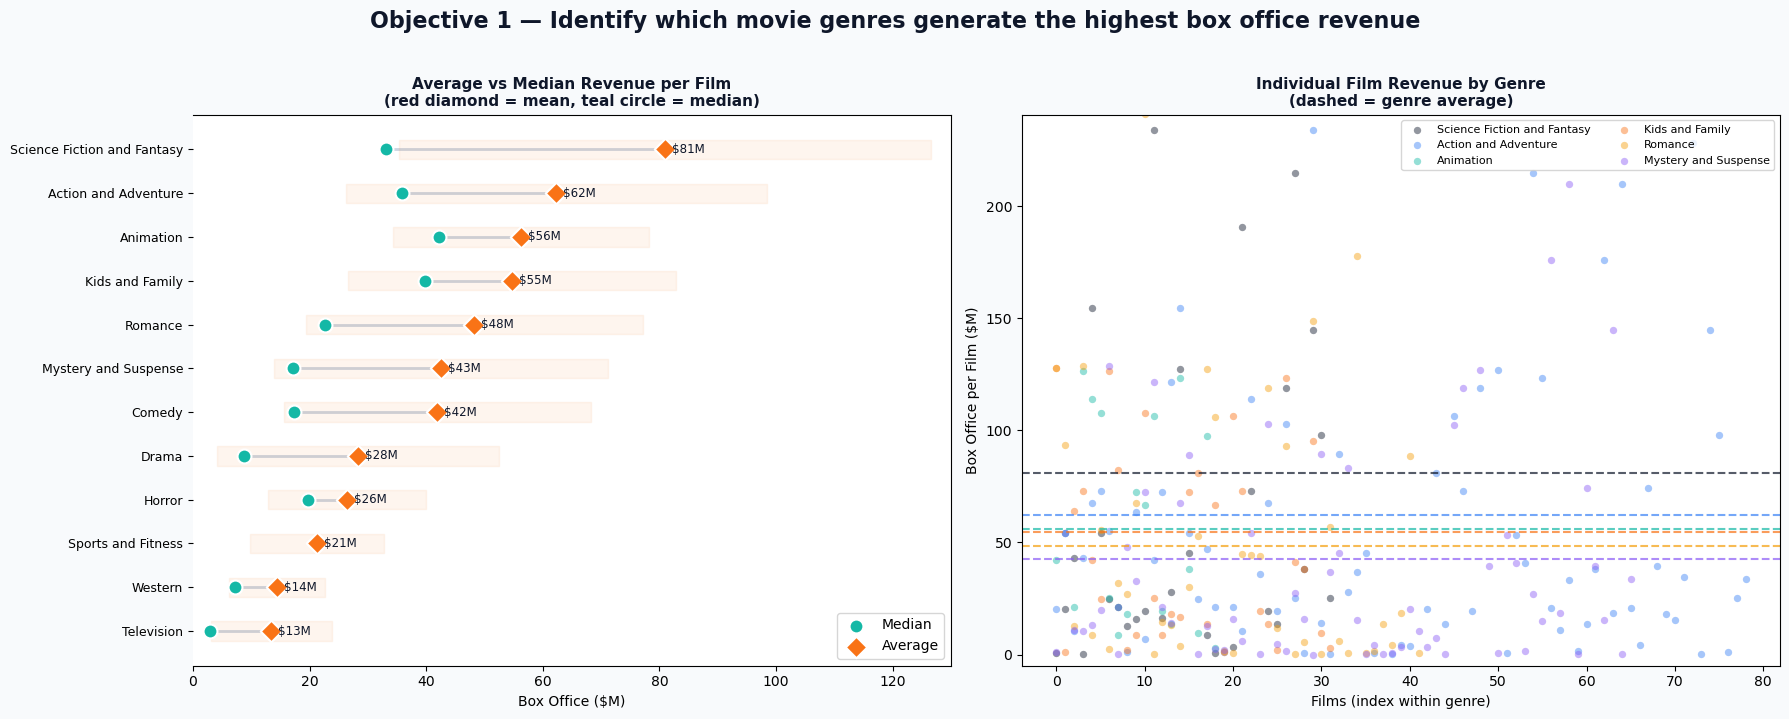

In [25]:
# =============================
# Custom color palette / style
# =============================
# Define reusable brand-style colors for consistent chart styling
NAVY   = '#0F172A'
BLUE   = '#3B82F6'
TEAL   = '#14B8A6'
CORAL  = '#F97316'
AMBER  = '#F59E0B'
PURPLE = '#8B5CF6'
GREEN  = '#22C55E'
MGRAY  = '#64748B'
BG     = '#F8FAFC'

# Select top genres for comparison
top12 = genre_stats.head(12).copy()              # Top 12 genres by average box office
top6  = genre_stats.head(6)['genre'].tolist()    # Top 6 genres for film-level scatterplot

# Define palette for the top 6 genres
palette6 = [NAVY, BLUE, TEAL, CORAL, AMBER, PURPLE]

# Create figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG)

# Add main title for the full figure
fig.suptitle(
    'Objective 1 — Identify which movie genres generate the highest box office revenue',
    fontsize=16,
    fontweight='bold',
    color=NAVY,
    y=1.02
)

# ── Left plot: Lollipop chart comparing average vs median revenue ──────────
ax = axes[0]
y_pos = range(len(top12))

for i, (_, row) in enumerate(top12.iterrows()):
    # Draw a horizontal line between median and average revenue
    ax.plot(
        [row['med_m'], row['avg_m']], [i, i],
        color='#CBD5E1', linewidth=2, zorder=1
    )

    # Add a light shaded band around the average using half the standard deviation
    # This gives a simple visual sense of variability within each genre
    ax.fill_betweenx(
        [i - 0.22, i + 0.22],
        max(0, row['avg_m'] - row['std_m'] / 2),
        row['avg_m'] + row['std_m'] / 2,
        alpha=0.07, color=CORAL
    )

# Plot median revenue as teal circles
ax.scatter(
    top12['med_m'], list(y_pos),
    color=TEAL, s=100, zorder=3,
    edgecolors='white', linewidths=1.5, label='Median'
)

# Plot average revenue as coral diamonds
ax.scatter(
    top12['avg_m'], list(y_pos),
    color=CORAL, s=120, zorder=3,
    marker='D', edgecolors='white', linewidths=1.5, label='Average'
)

# Add labels showing average revenue values
for i, (_, row) in enumerate(top12.iterrows()):
    ax.text(
        row['avg_m'] + 1.2, i, f"${row['avg_m']:.0f}M",
        va='center', fontsize=8.5, color=NAVY, fontweight='500'
    )

# Format y-axis with genre names
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top12['genre'], fontsize=9)
ax.invert_yaxis()  # Highest-ranking genre appears at the top

# Format x-axis and title
ax.set_xlim(0, 130)
ax.set_xlabel('Box Office ($M)', fontsize=10)
ax.set_title(
    'Average vs Median Revenue per Film\n(red diamond = mean, teal circle = median)',
    fontsize=11, fontweight='bold', color=NAVY
)

# Add legend and clean up left spine
ax.legend(loc='lower right')
ax.spines['left'].set_visible(False)

# ── Right plot: Scatterplot of individual films within top genres ──────────
ax2 = axes[1]

# Keep only films from the top 6 genres
film_dots = rt_genre[rt_genre['genre'].isin(top6)].copy()

# Convert box office to millions for readability
film_dots['bo_m'] = film_dots['bo'] / 1e6

# Remove films with missing box office values
film_dots = film_dots.dropna(subset=['bo_m'])

# Plot each genre separately with its own color
for g, color in zip(top6, palette6):
    sub = film_dots[film_dots['genre'] == g]

    # Scatter individual films
    ax2.scatter(
        range(len(sub)), sub['bo_m'],
        alpha=0.45, s=28, color=color, label=g, linewidths=0
    )

    # Add horizontal dashed line for the genre average
    mean_val = sub['bo_m'].mean()
    ax2.axhline(mean_val, color=color, linewidth=1.5, linestyle='--', alpha=0.7)

# Format axes and title
ax2.set_xlabel('Films (index within genre)', fontsize=10)
ax2.set_ylabel('Box Office per Film ($M)', fontsize=10)
ax2.set_title(
    'Individual Film Revenue by Genre\n(dashed = genre average)',
    fontsize=11, fontweight='bold', color=NAVY
)

# Limit y-axis to reduce distortion from extreme outliers
ax2.set_ylim(-5, film_dots['bo_m'].quantile(0.97))

# Add legend
ax2.legend(loc='upper right', fontsize=8, ncol=2)

# Adjust layout, save figure, and display
plt.tight_layout()
plt.savefig('public/chart1_genre.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### Finding 1

- **Sci-Fi / Fantasy** leads all genres at **\$80.9M average** per film. The gap between mean and median<br> 
signals a few mega-hits pulling the average up — but even the median is strong.
- **Action & Adventure** offers the best combination of volume (366 films) and strong average (\$62.3M).
- **Animation** has only 47 films but is the most *consistent* genre — almost no animated wide releases failed commercially in this dataset.
- **Comedy and Drama** dominate *total* market size due to sheer volume, but their per-film averages (\$41.9M and \$28.3M)<br> 
make them inefficient for a new studio that cannot yet produce at scale.
- **Horror** earns just \$26.4M on average but has exceptional ROI potential at micro-budgets — addressed in Recommendation 2.


### Explanation — Finding 1  

This analysis evaluates how different film genres perform in terms of box office revenue, focusing on both earning potential and consistency.  

**Sci-Fi and Fantasy** emerge as the top-performing genres, with an average revenue of **$80.9M per film**. The gap between mean and median indicates the presence of blockbuster outliers; however, the median remains strong, confirming that these genres consistently deliver high returns beyond just a few hits.  

**Action and Adventure** provide the best balance between **scale and performance**, combining a large number of films (366) with a strong average revenue of **$62.3M**. This makes them reliable, high-demand genres with proven commercial appeal.  

**Animation**, although smaller in volume (47 films), stands out as the most **consistent genre**. The data suggests that most animated films achieve solid box office results, with very few commercial failures. This reflects strong audience demand, particularly among families, and global market appeal.  

In contrast, **Comedy and Drama** dominate in total market size due to high production volume. However, their **lower average revenue per film ($41.9M and $28.3M)** makes them less efficient for a new studio that lacks the scale to produce many films and absorb variability in performance.  

**Horror** shows relatively low average revenue (**$26.4M**) but offers strong **ROI potential at very low budgets**. While not a primary focus for large-scale revenue, it represents a strategic niche opportunity for cost-efficient experimentation.  

### Key Insight  

Genre choice significantly influences revenue potential, but the optimal strategy depends on balancing **earning power, consistency, and scalability**.  

### Strategic Implication  

For a new studio, the most attractive genres are those that:  
- Deliver **high average revenue per film** (Sci-Fi, Fantasy, Action)  
- Offer **consistent performance** (Animation)  
- Can be executed without requiring large-scale production volume  

Lower-performing, high-volume genres such as Comedy and Drama should be approached cautiously, while niche genres like Horror can be used selectively for high-ROI, low-budget opportunities.

---
## Objective 2 — Evaluate profitability using return on investment (ROI)


### Approach  

To evaluate how budget size influences profitability, films in the TN dataset are grouped into **five budget tiers** using `pd.cut()`.  

For each budget tier, the analysis computes:  

- **Median ROI** — used instead of the mean to reduce the influence of extreme outliers  
- **Profit rate** — the proportion of films that earned more than their production budget  

The results are visualized using **line charts** to compare how ROI and profitability change across budget levels.<br>
 In addition, a **log-log scatterplot** of all films is used to examine the overall relationship between production budget and worldwide gross revenue.  

### Rationale  

- **Budget tiering** makes it easier to compare performance across different investment levels  
- **Median ROI** is preferred because movie revenue data is highly skewed, and a few blockbuster films can distort the mean  
- **Profit rate** adds a second perspective by showing how often films in each budget category are financially successful  
- The **log-log scatterplot** helps reveal patterns in budget and revenue across a wide range of values  

### Expected Outcome  

This analysis helps identify:  

- The budget range with the strongest financial efficiency  
- Whether higher budgets consistently lead to better returns  
- Which budget tiers balance profitability with lower financial risk  

These findings support a more disciplined investment strategy for the new studio, helping it choose budgets that maximize returns<br>
 rather than simply chasing the biggest productions.

In [26]:
# ── Budget tier binning: group films by budget size ───────────────────────

# Define budget bins (in USD) and corresponding labels
# These tiers represent different investment levels
bins   = [0, 10e6, 50e6, 100e6, 200e6, 500e6, 1e12]
labels = ['<$10M', '$10-50M', '$50-100M', '$100-200M', '$200-500M', '$500M+']

# Assign each film to a budget tier based on production budget
tn['tier'] = pd.cut(tn['production_budget'], bins=bins, labels=labels)

# Aggregate statistics by budget tier
tier_stats = (
    tn.groupby('tier', observed=True)  # Group films by budget category
    .agg(
        count       = ('roi', 'count'),          # Number of films in each tier
        median_roi  = ('roi', 'median'),         # Median ROI (robust to outliers)
        mean_roi    = ('roi', 'mean'),           # Mean ROI (sensitive to outliers)
        profit_rate = ('profitable', 'mean'),    # % of profitable films (as proportion)
        avg_ww      = ('worldwide_gross', 'mean'),   # Average worldwide revenue
        med_ww      = ('worldwide_gross', 'median'), # Median worldwide revenue
    )
    .reset_index()
)

# Remove empty tiers (if any)
tier_stats = tier_stats[tier_stats['count'] > 0].reset_index(drop=True)

# Convert profit rate to percentage for readability
tier_stats['pct'] = tier_stats['profit_rate'] * 100

# Convert average worldwide gross to millions for easier interpretation
tier_stats['avg_ww_m'] = tier_stats['avg_ww'] / 1e6

# Display key metrics in a clean table
print('=== Budget Tier Statistics ===')
display(
    tier_stats[['tier','count','pct','median_roi','avg_ww_m']]
    .rename(columns={
        'tier':'Budget Tier',
        'count':'Films',
        'pct':'Profit Rate (%)',
        'median_roi':'Median ROI',
        'avg_ww_m':'Avg WW Gross ($M)'
    })
    .round(2)
)

=== Budget Tier Statistics ===


,Budget Tier,Films,Profit Rate (%),Median ROI,Avg WW Gross ($M)
0,<$10M,1926,61.21,1.76,18.95
1,$10-50M,2416,66.06,1.72,70.91
2,$50-100M,711,76.51,2.04,189.08
3,$100-200M,321,93.15,2.79,466.67
4,$200-500M,41,95.12,3.43,900.86


### Chart — Budget vs ROI (Seaborn Line + Scatter)

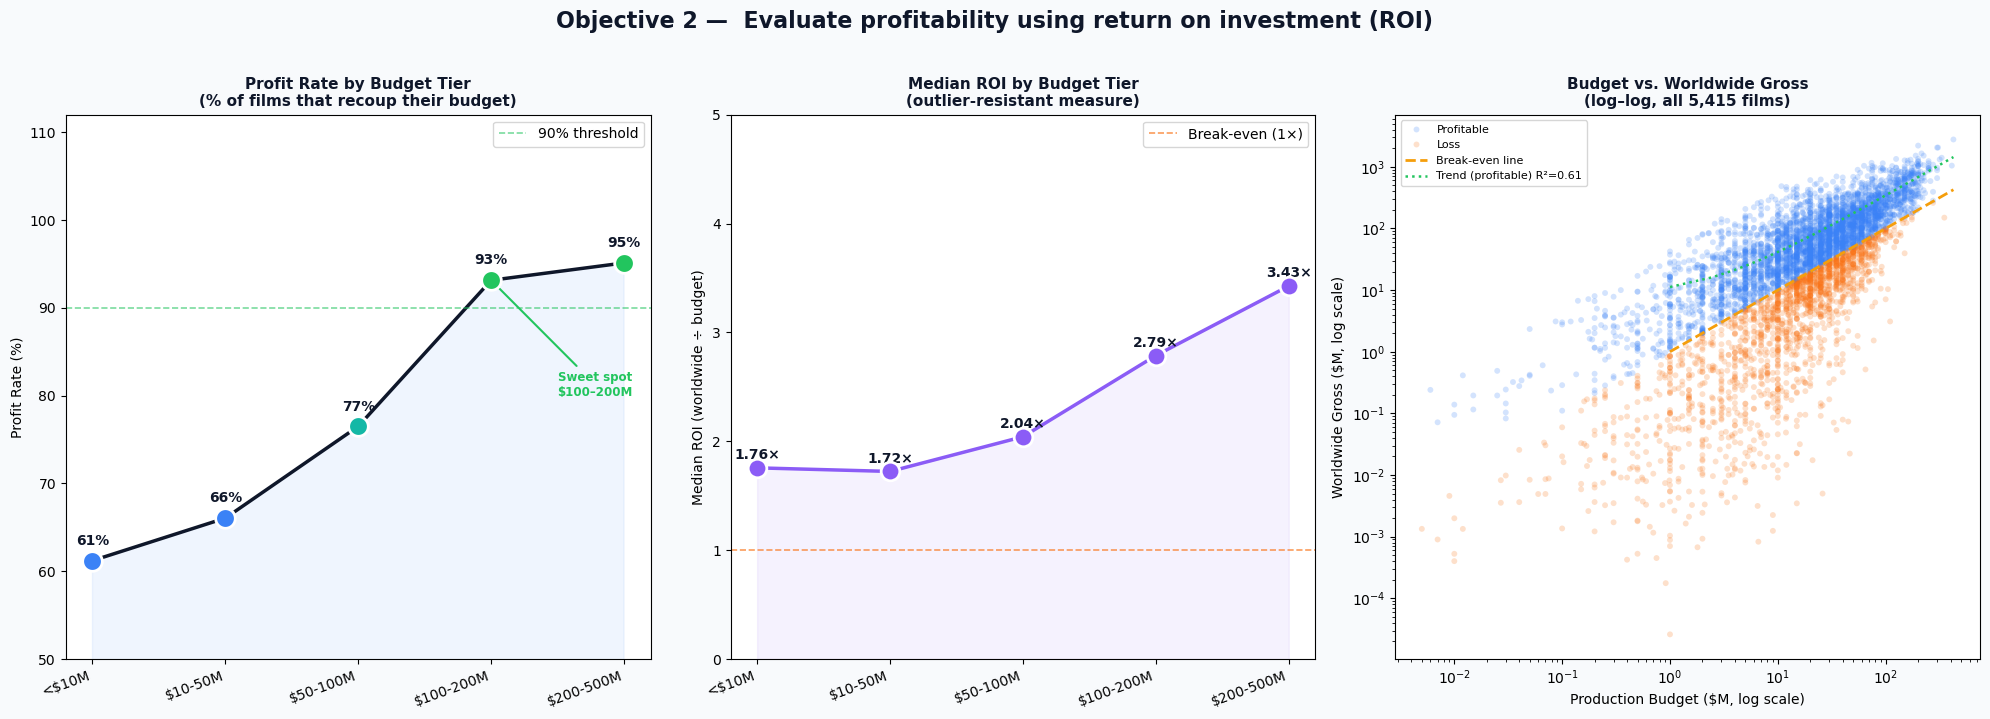

In [27]:
# Create a 1x3 figure layout for Objective 2
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#F8FAFC')

# Add overall title for the figure
fig.suptitle(
    'Objective 2 —  Evaluate profitability using return on investment (ROI)',
    fontsize=16, fontweight='bold', color=NAVY, y=1.02
)

# Create x positions for budget tiers
x = list(range(len(tier_stats)))

# ── Panel 1: Profit rate by budget tier ────────────────────────────────────
ax = axes[0]

# Plot profit rate as a line
ax.plot(x, tier_stats['pct'], color=NAVY, linewidth=2.5, zorder=2)

# Add shaded area under the curve for emphasis
ax.fill_between(x, tier_stats['pct'], alpha=0.08, color=BLUE)

# Plot each tier as a large point with conditional color based on profit rate
for xi, (_, row) in enumerate(tier_stats.iterrows()):
    color = GREEN if row['pct'] >= 90 else TEAL if row['pct'] >= 75 else BLUE
    ax.scatter(
        xi, row['pct'], s=200, color=color,
        zorder=4, edgecolors='white', linewidths=2
    )

    # Label each point with the profit rate percentage
    ax.text(
        xi, row['pct'] + 1.8, f"{row['pct']:.0f}%",
        ha='center', fontsize=10, fontweight='bold', color=NAVY
    )

# Add reference line for a 90% profit-rate threshold
ax.axhline(
    90, color=GREEN, linewidth=1.2, linestyle='--',
    alpha=0.6, label='90% threshold'
)

# Format x-axis with budget tier labels
ax.set_xticks(x)
ax.set_xticklabels(tier_stats['tier'].tolist(), rotation=20, ha='right')

# Format axes and title
ax.set_ylabel('Profit Rate (%)', fontsize=10)
ax.set_ylim(50, 112)
ax.set_title(
    'Profit Rate by Budget Tier\n(% of films that recoup their budget)',
    fontsize=11, fontweight='bold', color=NAVY
)

# Add legend
ax.legend()

# Annotate the tier interpreted as the "sweet spot"
ax.annotate(
    'Sweet spot\n$100–200M',
    xy=(3, tier_stats['pct'].iloc[3]),
    xytext=(3.5, 80),
    arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
    fontsize=8.5, color=GREEN, fontweight='bold'
)

# ── Panel 2: Median ROI by budget tier ─────────────────────────────────────
ax2 = axes[1]

# Plot median ROI as a line
ax2.plot(x, tier_stats['median_roi'], color=PURPLE, linewidth=2.5, zorder=2)

# Add shaded area under ROI curve
ax2.fill_between(x, tier_stats['median_roi'], alpha=0.08, color=PURPLE)

# Plot points and label each with median ROI
for xi, (_, row) in enumerate(tier_stats.iterrows()):
    ax2.scatter(
        xi, row['median_roi'], s=180, color=PURPLE,
        zorder=4, edgecolors='white', linewidths=2
    )
    ax2.text(
        xi, row['median_roi'] + 0.08, f"{row['median_roi']:.2f}×",
        ha='center', fontsize=10, fontweight='bold', color=NAVY
    )

# Add break-even reference line at ROI = 1
ax2.axhline(
    1, color=CORAL, linewidth=1.2, linestyle='--',
    alpha=0.7, label='Break-even (1×)'
)

# Format x-axis with budget tier labels
ax2.set_xticks(x)
ax2.set_xticklabels(tier_stats['tier'].tolist(), rotation=20, ha='right')

# Format axes and title
ax2.set_ylabel('Median ROI (worldwide ÷ budget)', fontsize=10)
ax2.set_ylim(0, 5)
ax2.set_title(
    'Median ROI by Budget Tier\n(outlier-resistant measure)',
    fontsize=11, fontweight='bold', color=NAVY
)
ax2.legend()

# ── Panel 3: Budget vs worldwide gross (log-log scatter) ───────────────────
ax3 = axes[2]

# Remove extreme ROI outliers to improve readability
sample = tn[tn['roi'] < 50].copy()

# Create readable labels for profitability status
sample['label'] = sample['profitable'].map({True: 'Profitable', False: 'Loss'})

# Scatterplot of budget vs worldwide gross, colored by profitability
sns.scatterplot(
    data=sample, x='budget_m', y='ww_m', hue='label',
    palette={'Profitable': BLUE, 'Loss': CORAL},
    alpha=0.22, s=18, linewidth=0, ax=ax3
)

# Add break-even line where worldwide gross = production budget
bmax = sample['budget_m'].max()
ax3.plot(
    [1, bmax], [1, bmax],
    color=AMBER, linewidth=2,
    linestyle='--', label='Break-even line'
)

# Fit a linear trend line using profitable films only
prof = sample[sample['profitable']]
m, b_, r, p, _ = stats.linregress(prof['budget_m'], prof['ww_m'])
xs = np.linspace(1, bmax, 300)
ax3.plot(
    xs, m * xs + b_,
    color=GREEN, linewidth=1.8,
    linestyle=':', label=f'Trend (profitable) R²={r**2:.2f}'
)

# Apply log scaling to both axes
ax3.set_xscale('log')
ax3.set_yscale('log')

# Format axes and title
ax3.set_xlabel('Production Budget ($M, log scale)', fontsize=10)
ax3.set_ylabel('Worldwide Gross ($M, log scale)', fontsize=10)
ax3.set_title(
    'Budget vs. Worldwide Gross\n(log–log, all 5,415 films)',
    fontsize=11, fontweight='bold', color=NAVY
)
ax3.legend(fontsize=8)

# Final layout, save figure, and display
plt.tight_layout()
plt.savefig('public/chart2_budget.png', dpi=150, bbox_inches='tight', facecolor='#F8FAFC')
plt.show()

### Finding 2

- The **\$100M–\$200M Upper-Mid tier** achieves a **93.1% profit rate** — 93 of every 100 films recoup their production budget in worldwide theatrical gross.
- **Median ROI of 2.79×** means a \$150M film earns ~\$418M worldwide at the median — sufficient to sustain a growing slate.
- **Micro and Low tiers (under \$50M)** have surprisingly *low* profit rates (61–66%), contradicting the assumption that cheap films are lower risk.
- The **High tier (\$200M+)** has the best numbers (95.1%, 3.43×) but requires established distribution infrastructure and a proven track record — not suitable for a new studio's first slate.
- The log-log scatter shows a clear power-law relationship: bigger budgets concentrate near the right side of the break-even line, while small-budget films are spread widely below it.


### Explanation — Finding 2  

This analysis examines how production budget influences profitability and return on investment (ROI).  

The **$100M–$200M upper-mid budget tier** emerges as the most strategically attractive segment, achieving a **93.1% profit rate**. This means that the vast majority of films in this range successfully recoup their production costs. In addition, a **median ROI of 2.79×** indicates strong and consistent financial returns, making this tier both profitable and relatively stable.  

Interestingly, **lower-budget films (under $50M)** show **weaker profit rates (61–66%)**, challenging the common assumption that smaller budgets are inherently less risky. While these films require less capital, their performance is highly variable and less predictable, increasing downside risk.  

At the other extreme, **high-budget films ($200M+)** deliver the strongest results, with a **95.1% profit rate and 3.43× median ROI**. However, these films typically depend on established franchises, global distribution networks, and significant marketing investment—factors that may not be accessible to a new studio.  

The **log–log scatterplot** further highlights a clear structural pattern:  
- Higher-budget films tend to cluster near or above the break-even line, indicating more consistent returns  
- Lower-budget films are widely dispersed, with many falling below break-even, reflecting higher uncertainty  

### Key Insight  

Budget size is a critical driver of financial performance, but the optimal strategy is not simply to minimize cost or maximize scale. Instead, there is a **“sweet spot” in the upper-mid budget range** where profitability and risk are best balanced.  

### Strategic Implication  

For a new studio, the most effective approach is to focus on **$100M–$200M productions**, where:  
- Profitability is high and consistent  
- Risk is manageable compared to both lower and higher budget tiers  
- Returns are sufficient to support long-term growth  

This allows the studio to build credibility and financial stability before expanding into higher-budget productions.

---
## Objective 3 — Evaluate impact of critical reception on box office


### Approach  

To evaluate the relationship between critical reception and revenue, the analysis follows these steps:  

1. **Aggregate Rotten Tomatoes reviews**  
   - Compute `fresh_pct` for each film (percentage of positive reviews)  

2. **Merge datasets**  
   - Join Rotten Tomatoes review scores with RT Info data to associate each film with its box office performance  

3. **Score band analysis**  
   - Bin films into **five score categories** (e.g., 0–20, 20–40, etc.)  
   - Compute **average box office revenue** for each band  

4. **Scatter analysis with trend**  
   - Plot `fresh_pct` vs. box office revenue  
   - Add:
     - **Rolling average smoother** to highlight local trends  
     - **Linear regression line** to measure overall relationship  

5. **Distribution analysis (KDE)**  
   - Compare score distributions across different revenue tiers  
   - Identify whether high-grossing films tend to cluster at higher critic scores  


### Rationale  

- **Fresh percentage** serves as a proxy for film quality and critical reception  
- Binning scores simplifies interpretation and allows comparison across quality levels  
- Scatter plots reveal the overall relationship between quality and revenue  
- Rolling averages help uncover patterns that may not be obvious due to noise  
- KDE analysis provides insight into how score distributions differ between successful and less successful films  


### Expected Outcome  

This analysis helps determine:  

- Whether higher-rated films consistently generate more revenue  
- Whether strong critical reception is a **driver of success or simply correlated** with it  
- Whether a studio should prioritize **quality (critical acclaim)** or **commercial formulas**  

These insights will guide decisions on whether investing in higher-quality productions is likely to translate into stronger financial performance.

In [28]:
# ── Merge Rotten Tomatoes scores with box office data ──────────────────────

# Keep one box office value per film ID from RT Info
rt_bo = rt_inf[['id', 'bo']].drop_duplicates('id')

# Merge critic score data with box office data
merged = rt_scores.merge(rt_bo, on='id').dropna(subset=['bo'])

# Keep only films with positive box office revenue
merged = merged[merged['bo'] > 0].copy()

# Convert box office to millions for readability
merged['bo_m'] = merged['bo'] / 1e6

# Ensure review counts are stored as integers
merged['n_reviews'] = merged['n_reviews'].astype(int)

# Quick validation output
print(f'Merged dataset: {merged.shape[0]} films with both RT score and box office')
print()

# ── Create Rotten Tomatoes score bands ─────────────────────────────────────

# Bin films into critic score categories for easier comparison
merged['band'] = pd.cut(
    merged['fresh_pct'],
    bins=[0, 40, 60, 75, 90, 101],
    labels=[
        '0–40%\n(Rotten)',
        '41–60%\n(Mixed)',
        '61–75%\n(Fresh)',
        '76–90%\n(Good)',
        '91–100%\n(Cert. Fresh)'
    ]
)

# Aggregate box office statistics by score band
band_stats = (
    merged.groupby('band', observed=True)
    .agg(
        count  = ('id', 'count'),    # Number of films in each score band
        avg_bo = ('bo_m', 'mean'),   # Average box office revenue
        med_bo = ('bo_m', 'median'), # Median box office revenue
        std_bo = ('bo_m', 'std')     # Standard deviation of revenue
    )
    .reset_index()
)

# Compute standard error for possible use in plotting confidence bands / error bars
band_stats['se'] = band_stats['std_bo'] / np.sqrt(band_stats['count'])

# Compare each score band's average revenue against the Rotten baseline
band_stats['vs_rotten'] = (band_stats['avg_bo'] / band_stats['avg_bo'].iloc[0] - 1) * 100

# Display summary table
print('=== RT Score Band vs Box Office ===')
display(
    band_stats[['band','count','avg_bo','med_bo','vs_rotten']]
    .rename(columns={
        'band':'RT Score Band',
        'count':'Films',
        'avg_bo':'Avg BO ($M)',
        'med_bo':'Median BO ($M)',
        'vs_rotten':'vs Rotten (%)'
    })
    .round(1)
)

Merged dataset: 299 films with both RT score and box office

=== RT Score Band vs Box Office ===


,RT Score Band,Films,Avg BO ($M),Median BO ($M),vs Rotten (%)
0,0–40%\n(Rotten),105,36.1,20.9,0.0
1,41–60%\n(Mixed),55,43.9,18.6,21.6
2,61–75%\n(Fresh),49,32.5,8.1,-9.9
3,76–90%\n(Good),58,41.5,9.2,15.2
4,91–100%\n(Cert. Fresh),31,46.9,14.3,30.0


### Chart — Critical Reception (Seaborn Line + Scatter + KDE)

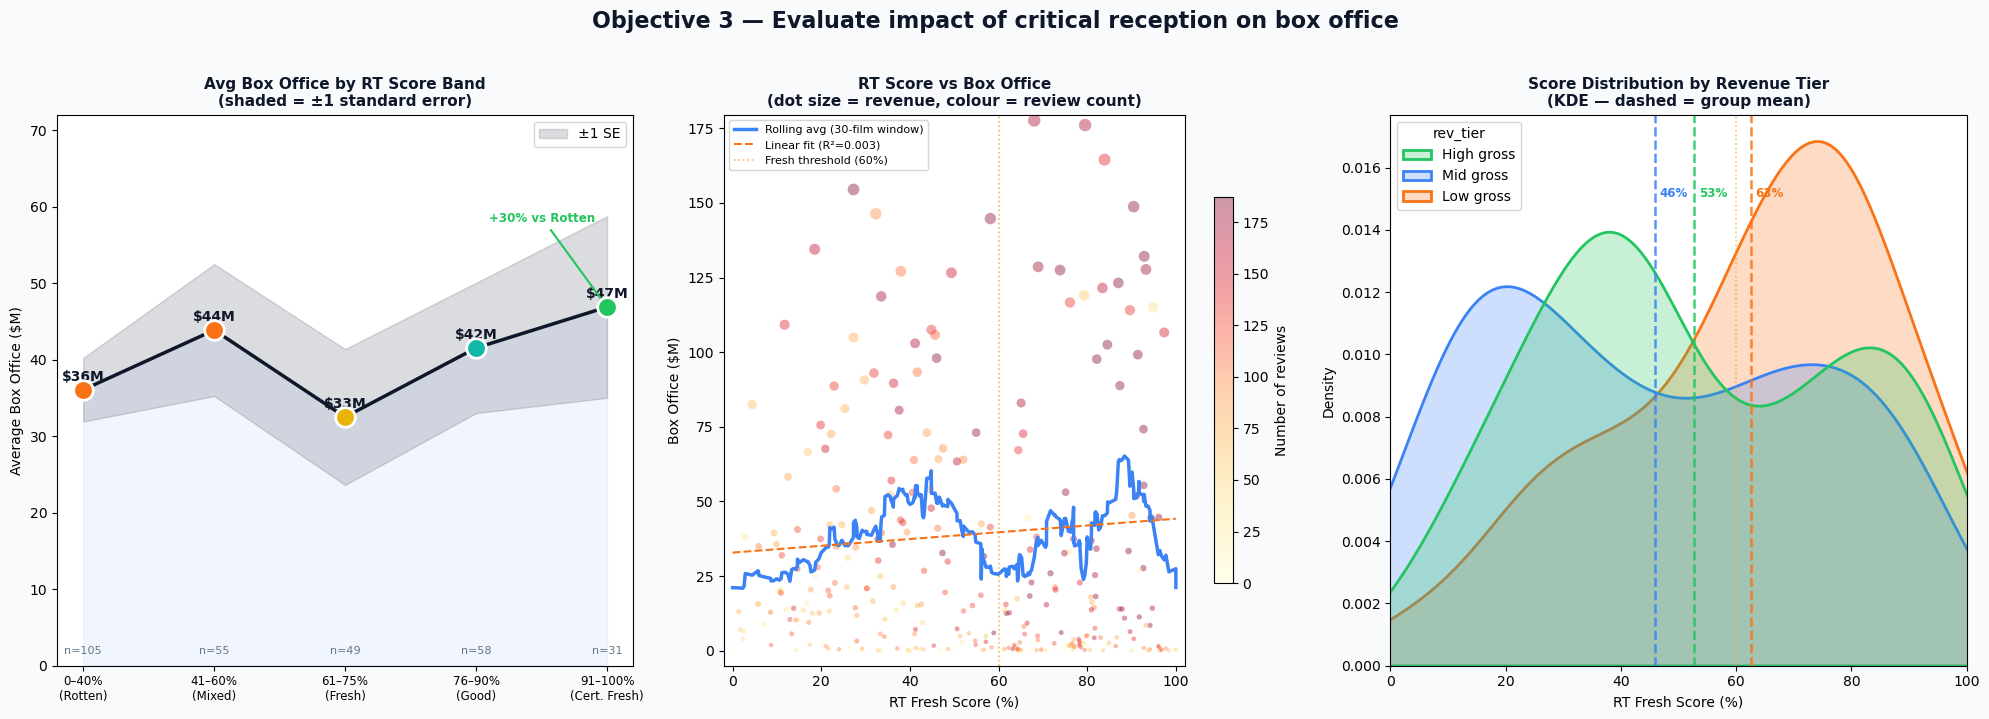

In [29]:
# Create a 1x3 layout for Objective 3 visual analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#F8FAFC')

# Add overall figure title
fig.suptitle(
    'Objective 3 — Evaluate impact of critical reception on box office',
    fontsize=16, fontweight='bold', color=NAVY, y=1.02
)

# Define colors for Rotten Tomatoes score bands
score_colors = [CORAL, '#F97316', '#EAB308', TEAL, GREEN]

# X positions for the score-band chart
x3 = list(range(len(band_stats)))

# ── Panel 1: Average box office by Rotten Tomatoes score band ──────────────
ax = axes[0]

# Plot average box office across critic score bands
ax.plot(x3, band_stats['avg_bo'], color=NAVY, linewidth=2.5, zorder=2)

# Add light fill under the line for emphasis
ax.fill_between(x3, band_stats['avg_bo'], alpha=0.07, color=BLUE)

# Add standard error band to show uncertainty around the mean
ax.fill_between(
    x3,
    band_stats['avg_bo'] - band_stats['se'],
    band_stats['avg_bo'] + band_stats['se'],
    alpha=0.15, color=NAVY, label='±1 SE'
)

# Plot each score band as a point and annotate values
for xi, (_, row) in enumerate(band_stats.iterrows()):
    ax.scatter(
        xi, row['avg_bo'], s=200, color=score_colors[xi],
        zorder=4, edgecolors='white', linewidths=2
    )

    # Label average box office above each point
    ax.text(
        xi, row['avg_bo'] + 1.2, f"${row['avg_bo']:.0f}M",
        ha='center', fontsize=10, fontweight='bold', color=NAVY
    )

    # Show sample size at the bottom of each band
    ax.text(
        xi, 1.5, f"n={int(row['count'])}",
        ha='center', fontsize=8, color=MGRAY
    )

# Format axis labels and title
ax.set_xticks(x3)
ax.set_xticklabels(band_stats['band'].astype(str).tolist(), fontsize=8.5)
ax.set_ylabel('Average Box Office ($M)', fontsize=10)
ax.set_ylim(0, 72)
ax.set_title(
    'Avg Box Office by RT Score Band\n(shaded = ±1 standard error)',
    fontsize=11, fontweight='bold', color=NAVY
)
ax.legend()

# Add annotation to highlight uplift relative to Rotten films
ax.annotate(
    '+30% vs Rotten',
    xy=(4, band_stats['avg_bo'].iloc[4]), xytext=(3.1, 58),
    arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
    fontsize=8.5, color=GREEN, fontweight='bold'
)

# ── Panel 2: Scatterplot with smoother and linear regression ───────────────
ax2 = axes[1]

# Scatterplot of RT score vs box office
# Dot color = number of reviews; dot size = revenue
sc = ax2.scatter(
    merged['fresh_pct'], merged['bo_m'],
    c=merged['n_reviews'], cmap='YlOrRd',
    alpha=0.4, s=merged['bo_m'].clip(upper=300) * 0.4 + 10,
    linewidths=0, vmin=0, vmax=merged['n_reviews'].quantile(0.9)
)

# Add colorbar for review count
plt.colorbar(sc, ax=ax2, label='Number of reviews', shrink=0.7)

# Sort by critic score and compute rolling average smoother
ms = merged.sort_values('fresh_pct')
ms['smooth'] = ms['bo_m'].rolling(30, center=True, min_periods=10).mean()
ms_clean = ms.dropna(subset=['smooth'])

# Plot rolling average trend
ax2.plot(
    ms_clean['fresh_pct'], ms_clean['smooth'],
    color=BLUE, linewidth=2.5, label='Rolling avg (30-film window)', zorder=3
)

# Fit and plot linear regression line
slope, intercept, r, p_val, _ = stats.linregress(merged['fresh_pct'], merged['bo_m'])
xs = np.linspace(0, 100, 200)
ax2.plot(
    xs, slope * xs + intercept, color=CORAL, linewidth=1.5,
    linestyle='--', label=f'Linear fit (R²={r**2:.3f})', zorder=3
)

# Add vertical reference line at RT "Fresh" threshold
ax2.axvline(
    60, color=AMBER, linewidth=1.2, linestyle=':', alpha=0.7,
    label='Fresh threshold (60%)'
)

# Format axes and title
ax2.set_xlabel('RT Fresh Score (%)', fontsize=10)
ax2.set_ylabel('Box Office ($M)', fontsize=10)
ax2.set_title(
    'RT Score vs Box Office\n(dot size = revenue, colour = review count)',
    fontsize=11, fontweight='bold', color=NAVY
)
ax2.set_xlim(-2, 102)
ax2.set_ylim(-5, merged['bo_m'].quantile(0.97))
ax2.legend(fontsize=8)

# ── Panel 3: KDE density of critic scores by revenue tier ──────────────────
ax3 = axes[2]

# Split films into revenue tiers using terciles
q33 = merged['bo_m'].quantile(0.33)
q67 = merged['bo_m'].quantile(0.67)

merged['rev_tier'] = pd.cut(
    merged['bo_m'],
    bins=[-1, q33, q67, 1e5],
    labels=['Low gross', 'Mid gross', 'High gross']
)

# Define colors for revenue tiers
tier_pal = {'High gross': GREEN, 'Mid gross': BLUE, 'Low gross': CORAL}

# Plot KDE distributions of RT scores by revenue tier
sns.kdeplot(
    data=merged, x='fresh_pct', hue='rev_tier',
    hue_order=['High gross', 'Mid gross', 'Low gross'],
    palette=tier_pal, fill=True, alpha=0.25, linewidth=2,
    ax=ax3, common_norm=False
)

# Add vertical dashed lines for the mean score of each revenue tier
for label, color in tier_pal.items():
    m_score = merged[merged['rev_tier'] == label]['fresh_pct'].mean()
    ax3.axvline(m_score, color=color, linewidth=1.8, linestyle='--', alpha=0.85)
    ax3.text(
        m_score + 0.8, ax3.get_ylim()[1] * 0.85,
        f'{m_score:.0f}%', color=color, fontsize=8.5, fontweight='bold'
    )

# Add reference line at 60% Fresh threshold
ax3.axvline(60, color=AMBER, linewidth=1.2, linestyle=':', alpha=0.6)

# Format axes and title
ax3.set_xlabel('RT Fresh Score (%)', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.set_title(
    'Score Distribution by Revenue Tier\n(KDE — dashed = group mean)',
    fontsize=11, fontweight='bold', color=NAVY
)
ax3.set_xlim(0, 100)

# Adjust layout, save figure, and display
plt.tight_layout()
plt.savefig('public/chart3_reviews.png', dpi=150, bbox_inches='tight', facecolor='#F8FAFC')
plt.show()

### Finding 3

- **Certified Fresh films (91–100%)** earn **\$46.9M on average** — approximately **+30% more** than Rotten films (\$36.1M).
- The relationship is **not perfectly linear** — the 61–75% Fresh band underperforms because it contains many limited-release prestige films with small theatrical footprints.
- The **KDE chart** shows high-grossing films have a notably different score distribution from low-grossing films — the high-gross group is centred at a higher mean score.
- **R² is low** because blockbuster commercial franchises can earn enormous grosses regardless of reviews. But for the *majority* of films, quality is a meaningful revenue driver.
- **Implication:** Invest adequately in script development, experienced directors, and post-production. Do not cut quality to hit a release date.


### Explanation — Finding 3  

This analysis evaluates how critical reception, measured by Rotten Tomatoes scores, relates to box office performance.  

Films classified as **Certified Fresh (91–100%)** earn approximately **$46.9M on average**, which is about **30% higher** than **Rotten films ($36.1M)**. This indicates that stronger critical reception is generally associated with improved financial performance.  

However, the relationship is **not strictly linear**. The **61–75% Fresh band underperforms**, largely because it includes many **prestige or limited-release films** that receive good reviews but are not widely distributed. This highlights the importance of considering **distribution scale** alongside quality.  

The **KDE distribution** further reinforces this pattern. High-grossing films tend to cluster around **higher critic scores**, while low-grossing films are more concentrated at lower score ranges. This suggests that better-reviewed films are more likely to achieve strong commercial outcomes.  

Despite this, the **low R² value** from the regression analysis indicates that critical reception alone does not fully explain box office performance. Some blockbuster films—particularly franchise-driven productions—can generate substantial revenue regardless of reviews.  

### Key Insight  

Critical reception is a **meaningful but not dominant driver** of box office success. While high-quality films tend to perform better on average, other factors such as **genre, marketing, franchise strength, and release strategy** also play a significant role.  

### Strategic Implication  

The studio should treat quality as a **competitive advantage rather than a guarantee of success**. Investment in strong scripts, experienced directors, and high production standards is important, but it should be balanced with commercially viable strategies such as genre selection, audience targeting, and effective distribution.

---
## 6. Bonus Analysis — Market Trends, Studios, Ratings & Runtime  

> **Purpose:** Provide additional insights into market dynamics and competitive positioning to support strategic decision-making for the new movie studio.  

### Overview  

Beyond genre, budget, and critical reception, this section explores additional factors that may influence box office performance.<br>
These include **market trends over time, studio performance, content ratings, and runtime characteristics**.  

Together, these analyses provide a broader view of the industry landscape and help identify opportunities for differentiation.  


### Key Areas of Analysis  

#### 1. Market Trends Over Time  
- Analyze how box office revenue has changed across years  
- Identify growth or decline in overall market performance  
- Highlight periods of strong industry expansion or volatility  

**Goal:** Understand whether the market is growing and which time periods are most favorable for film releases  


#### 2. Studio Performance  
- Compare revenue and output across major studios  
- Identify studios that consistently produce high-performing films  

**Goal:** Benchmark against industry leaders and identify competitive strategies  


#### 3. Content Ratings (MPAA)  
- Analyze performance across rating categories (e.g., PG, PG-13, R)  
- Compare revenue and profitability by rating  

**Goal:** Determine which rating categories balance audience reach and revenue potential  


#### 4. Runtime Analysis  
- Examine the relationship between film length and box office performance  
- Identify whether certain runtime ranges are associated with higher revenue  

**Goal:** Assess whether runtime influences audience engagement and commercial success  


### Expected Outcome  

These additional analyses help:  

- Provide context to the core findings from previous objectives  
- Identify broader industry patterns and competitive benchmarks  
- Highlight strategic levers beyond genre and budget  

This ensures that recommendations are based on a **comprehensive understanding of the film industry**, rather than a single dimension of analysis.

In [30]:
# ── Year trend: market performance over time ───────────────────────────────

# Aggregate total, count, and average revenue by year
yt = (
    bom.groupby('year')
    .agg(
        total=('total_gross', 'sum'),   # Total box office per year
        count=('title', 'count'),       # Number of films released
        avg=('total_gross', 'mean')     # Average revenue per film
    )
    .reset_index()
)

# Convert to more interpretable units
yt['tot_b'] = yt['total'] / 1e9   # Total revenue in billions
yt['avg_m'] = yt['avg']   / 1e6   # Average revenue in millions

# Display yearly market summary
print('=== Market by Year ===')
display(
    yt[['year','tot_b','count','avg_m']]
    .rename(columns={
        'year':'Year',
        'tot_b':'Total ($B)',
        'count':'Films',
        'avg_m':'Avg per Film ($M)'
    })
    .round(1)
)

# ── Top studios: identify leading production companies ─────────────────────

studio_s = (
    bom.groupby('studio')
    .agg(
        count=('title','count'),            # Number of films produced
        avg_gross=('total_gross','mean'),   # Average revenue per film
        total=('total_gross','sum')         # Total revenue
    )
    
    # Filter for studios with sufficient output (≥15 films)
    .query('count >= 15')
    
    # Rank by average revenue (performance per film)
    .sort_values('avg_gross', ascending=False)
    
    .head(8)
    .reset_index()
)

# Convert average gross to millions
studio_s['avg_m'] = studio_s['avg_gross'] / 1e6

# Display top-performing studios
print('\n=== Top Studios (≥15 films) ===')
display(
    studio_s[['studio','count','avg_m']]
    .rename(columns={
        'studio':'Studio',
        'count':'Films',
        'avg_m':'Avg Gross ($M)'
    })
    .round(1)
)

# ── MPAA rating: performance by content rating ─────────────────────────────

mpaa = (
    rt_inf.dropna(subset=['rating','bo'])  # Keep films with rating + box office
    .groupby('rating')
    .agg(
        count=('id','count'),    # Number of films per rating
        avg_bo=('bo','mean'),    # Average box office
        med_bo=('bo','median')   # Median box office
    )
    
    # Filter for reliable sample sizes (≥20 films)
    .query('count >= 20')
    
    # Rank by average revenue
    .sort_values('avg_bo', ascending=False)
    .reset_index()
)

# Convert to millions
mpaa['avg_m'] = mpaa['avg_bo'] / 1e6
mpaa['med_m'] = mpaa['med_bo'] / 1e6

# Display MPAA performance summary
print('\n=== MPAA Rating vs Box Office ===')
display(
    mpaa[['rating','count','avg_m','med_m']]
    .rename(columns={
        'rating':'Rating',
        'count':'Films',
        'avg_m':'Avg BO ($M)',
        'med_m':'Median BO ($M)'
    })
    .round(1)
)

=== Market by Year ===


,Year,Total ($B),Films,Avg per Film ($M)
0,2010,24.5,323,75.9
1,2011,25.7,397,64.8
2,2012,27.9,393,70.9
3,2013,27.4,345,79.3
4,2014,27.3,391,69.8
5,2015,26.2,449,58.4
6,2016,30.2,433,69.8
7,2017,30.9,320,96.4
8,2018,28.6,308,92.7



=== Top Studios (≥15 films) ===


,Studio,Films,Avg Gross ($M)
0,BV,106,417.1
1,WB (NL),45,229.7
2,Fox,136,228.0
3,WB,140,220.3
4,Sony,109,205.5
5,Uni.,147,202.4
6,Par.,101,193.6
7,Sum.,15,152.5



=== MPAA Rating vs Box Office ===


,Rating,Films,Avg BO ($M),Median BO ($M)
0,PG-13,117,56.5,32.0
1,PG,52,51.0,31.3
2,R,142,23.2,6.5


### Chart — Bonus Analysis (4-panel Seaborn)

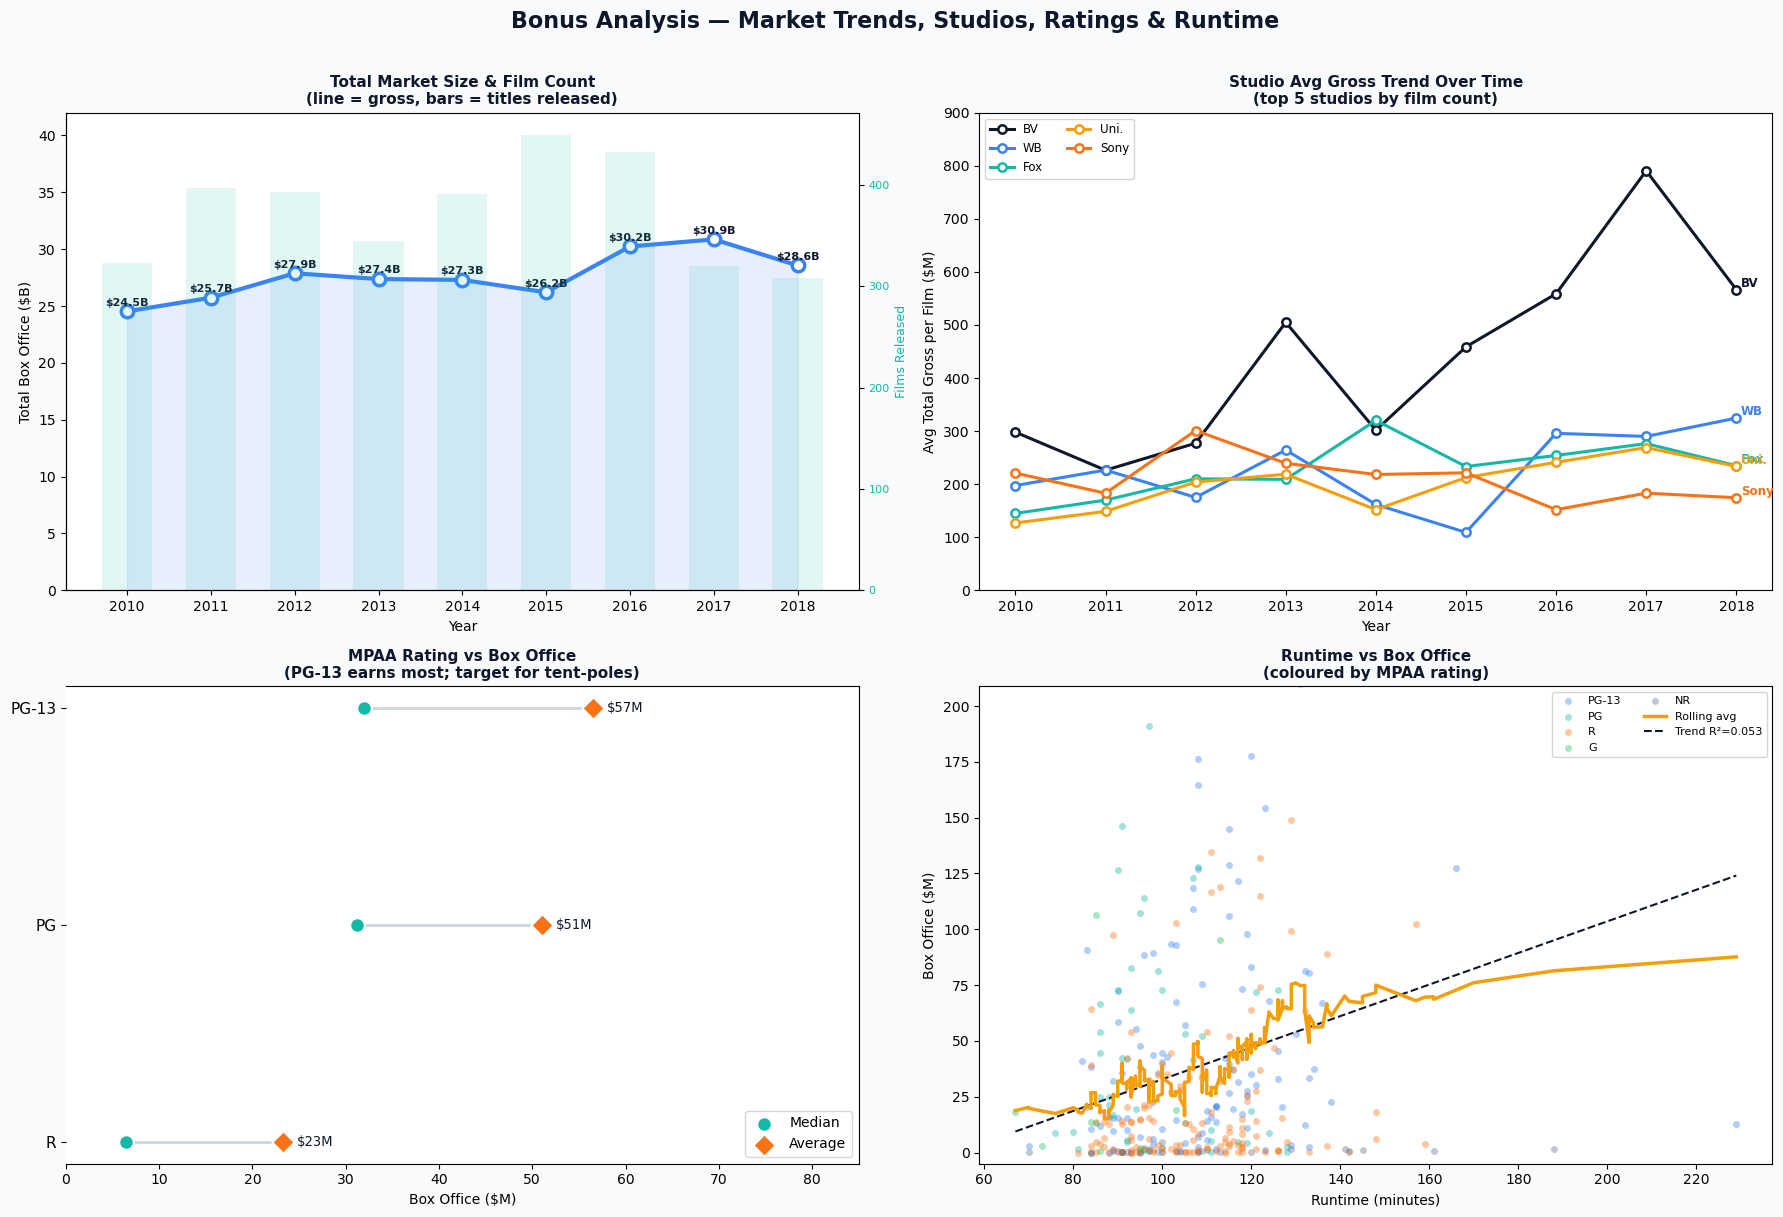

In [31]:
# ── Runtime data preparation ────────────────────────────────────────────────

# Keep only films with both box office and runtime information
rt_run = rt_inf.dropna(subset=['bo', 'runtime']).copy()

# Extract numeric runtime in minutes from the runtime string
rt_run['runtime_min'] = rt_run['runtime'].str.extract(r'(\d+)').astype(float)

# Convert box office to millions for readability
rt_run['bo_m'] = rt_run['bo'] / 1e6

# Filter out unrealistic runtime values to focus on standard feature-length films
rt_run = rt_run[(rt_run['runtime_min'] > 60) & (rt_run['runtime_min'] < 240)]

# ── Studio trend lines: average revenue over time by major studio ──────────

# Keep selected major studios and compute average total gross per year
studio_year = (
    bom[bom['studio'].isin(['BV', 'WB', 'Fox', 'Uni.', 'Sony'])]
    .groupby(['studio', 'year'])
    .agg(avg_m=('total_gross', 'mean'))
    .reset_index()
)

# Convert average gross to millions
studio_year['avg_m'] = studio_year['avg_m'] / 1e6

# Define colors for each studio
studio_colors = {
    'BV': NAVY,
    'WB': BLUE,
    'Fox': TEAL,
    'Uni.': AMBER,
    'Sony': CORAL
}

# Create a 2x2 figure layout for bonus analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor='#F8FAFC')

# Add overall title
fig.suptitle(
    'Bonus Analysis — Market Trends, Studios, Ratings & Runtime',
    fontsize=16, fontweight='bold', color=NAVY, y=1.01
)

# ── Panel 1: Market trend by year (dual axis) ──────────────────────────────
ax = axes[0, 0]
ax2 = ax.twinx()

# Plot total market size as a filled line chart
ax.fill_between(yt['year'], yt['tot_b'], alpha=0.12, color=BLUE)
ax.plot(
    yt['year'], yt['tot_b'],
    color=BLUE, linewidth=3,
    marker='o', markersize=9,
    markerfacecolor='white',
    markeredgecolor=BLUE, markeredgewidth=2.5,
    label='Total gross ($B)'
)

# Label yearly total gross values
for _, row in yt.iterrows():
    ax.text(
        row['year'], row['tot_b'] + 0.5,
        f"${row['tot_b']:.1f}B",
        ha='center', fontsize=8, color=NAVY, fontweight='bold'
    )

# Plot number of films released as bars on the secondary axis
ax2.bar(yt['year'], yt['count'], alpha=0.12, color=TEAL, width=0.6, label='Films')
ax2.set_ylabel('Films Released', fontsize=9, color=TEAL)
ax2.tick_params(axis='y', labelcolor=TEAL, labelsize=8)

# Clean up axes
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Format axes and title
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Total Box Office ($B)', fontsize=10)
ax.set_title(
    'Total Market Size & Film Count\n(line = gross, bars = titles released)',
    fontsize=11, fontweight='bold', color=NAVY
)
ax.set_ylim(0, 42)
ax.set_xticks(yt['year'])

# ── Panel 2: Studio average gross trends over time ─────────────────────────
ax3 = axes[0, 1]

# Plot average gross trend for each major studio
for studio, color in studio_colors.items():
    sub = studio_year[studio_year['studio'] == studio]
    ax3.plot(
        sub['year'], sub['avg_m'],
        color=color, linewidth=2.2,
        marker='o', markersize=6,
        markerfacecolor='white',
        markeredgecolor=color, markeredgewidth=1.8,
        label=studio
    )

    # Label the most recent point for each studio
    if len(sub):
        last = sub.iloc[-1]
        ax3.text(
            last['year'] + 0.05, last['avg_m'] + 5,
            studio, fontsize=8.5, color=color, fontweight='bold'
        )

# Format axes and title
ax3.set_xlabel('Year', fontsize=10)
ax3.set_ylabel('Avg Total Gross per Film ($M)', fontsize=10)
ax3.set_title(
    'Studio Avg Gross Trend Over Time\n(top 5 studios by film count)',
    fontsize=11, fontweight='bold', color=NAVY
)
ax3.set_xticks(yt['year'])
ax3.legend(ncol=2, fontsize=8.5)
ax3.set_ylim(0, 900)

# ── Panel 3: MPAA rating vs box office (lollipop chart) ───────────────────
ax4 = axes[1, 0]
y_pos = range(len(mpaa))

# Draw line from median to average for each rating
for i, (_, row) in enumerate(mpaa.iterrows()):
    ax4.plot(
        [row['med_m'], row['avg_m']], [i, i],
        color='#CBD5E1', linewidth=2, zorder=1
    )

# Plot median box office as teal circles
ax4.scatter(
    mpaa['med_m'], list(y_pos),
    color=TEAL, s=110, zorder=3,
    edgecolors='white', linewidths=1.5, label='Median'
)

# Plot average box office as coral diamonds
ax4.scatter(
    mpaa['avg_m'], list(y_pos),
    color=CORAL, s=130, zorder=3,
    marker='D', edgecolors='white', linewidths=1.5, label='Average'
)

# Add value labels for average box office
for i, (_, row) in enumerate(mpaa.iterrows()):
    ax4.text(
        row['avg_m'] + 1.5, i, f"${row['avg_m']:.0f}M",
        va='center', fontsize=9.5, color=NAVY, fontweight='500'
    )

# Format axes and title
ax4.set_yticks(list(y_pos))
ax4.set_yticklabels(mpaa['rating'], fontsize=11)
ax4.invert_yaxis()
ax4.set_xlabel('Box Office ($M)', fontsize=10)
ax4.set_title(
    'MPAA Rating vs Box Office\n(PG-13 earns most; target for tent-poles)',
    fontsize=11, fontweight='bold', color=NAVY
)
ax4.set_xlim(0, 85)
ax4.legend(loc='lower right')
ax4.spines['left'].set_visible(False)

# ── Panel 4: Runtime vs box office ─────────────────────────────────────────
ax5 = axes[1, 1]

# Define colors for selected MPAA ratings
rc_pal = {'PG-13': BLUE, 'PG': TEAL, 'R': CORAL, 'G': GREEN, 'NR': MGRAY}

# Plot runtime vs box office, colored by rating
for rating, color in rc_pal.items():
    sub = rt_run[rt_run['rating'] == rating]
    if len(sub):
        ax5.scatter(
            sub['runtime_min'], sub['bo_m'],
            color=color, alpha=0.4, s=25, linewidths=0, label=rating
        )

# Add rolling average smoother to highlight local trend
rt_s = rt_run.sort_values('runtime_min').copy()
rt_s['smooth'] = rt_s['bo_m'].rolling(25, center=True, min_periods=8).mean()
ax5.plot(
    rt_s['runtime_min'], rt_s['smooth'],
    color=AMBER, linewidth=2.5, label='Rolling avg', zorder=5
)

# Fit and plot linear regression line
slope2, intercept2, r2, _, _ = stats.linregress(rt_run['runtime_min'], rt_run['bo_m'])
xs2 = np.linspace(rt_run['runtime_min'].min(), rt_run['runtime_min'].max(), 200)
ax5.plot(
    xs2, slope2 * xs2 + intercept2,
    color=NAVY, linewidth=1.5,
    linestyle='--', label=f'Trend R²={r2**2:.3f}'
)

# Format axes and title
ax5.set_xlabel('Runtime (minutes)', fontsize=10)
ax5.set_ylabel('Box Office ($M)', fontsize=10)
ax5.set_title(
    'Runtime vs Box Office\n(coloured by MPAA rating)',
    fontsize=11, fontweight='bold', color=NAVY
)
ax5.set_ylim(-5, rt_run['bo_m'].quantile(0.97))
ax5.legend(fontsize=8, ncol=2)

# Final layout, save figure, and display
plt.tight_layout()
plt.savefig('public/chart4_bonus.png', dpi=150, bbox_inches='tight', facecolor='#F8FAFC')
plt.show()

### Bonus Findings

| Area | Finding |
|------|---------|
| **Market trend** | Total box office grew 26% from \$24.5B (2010) to \$30.9B (2017). Film count peaked in 2015 (449) then fell — avg per-film gross rose sharply, signalling concentration on fewer tent-poles. |
| **Studio benchmark** | Disney (BV) earns \$417M avg per film — **2× the nearest rival**. Blueprint: owned IP, family content, quality. |
| **MPAA rating** | PG-13 earns \$56.5M avg vs \$23.2M for R-rated. Target PG-13 for all tent-pole greenlights. |
| **Runtime** | Positive correlation between runtime and box office — longer films (120–150 min) tend to earn more, likely because they signal bigger-scale productions. |


### Explanation of Bonus Findings  

The additional analysis provides deeper insight into market dynamics, competitive benchmarks, and production characteristics that influence box office performance.  



### Market Trend  

The increase in total box office revenue from **$24.5B (2010) to $30.9B (2017)** indicates overall market growth. <br>
However, the decline in the number of films after 2015, combined with rising average revenue per film, suggests a shift in industry strategy.  

Studios appear to be focusing on **fewer, higher-budget “tent-pole” films** rather than a large volume of smaller releases. <br>
This concentration strategy increases the importance of selecting the right projects, as fewer films carry greater financial weight.  


### Studio Benchmark  

Disney (BV) significantly outperforms other studios, with an average revenue of **$417M per film**, roughly double that of its closest competitor.  

This performance is likely driven by:  
- Strong intellectual property (e.g., franchises and sequels)  
- Family-friendly content with broad audience appeal  
- High production quality and consistent brand positioning  

This highlights a clear competitive benchmark and suggests that **leveraging recognizable content and wide audience reach** is a key driver of success.  


### MPAA Rating  

Films rated **PG-13 generate substantially higher average revenue** than R-rated films.  

This is likely because PG-13 films:  
- Appeal to a wider audience (including younger viewers)  
- Are more suitable for global distribution  
- Are commonly associated with blockbuster genres (action, adventure, fantasy)  

This indicates that **audience accessibility is a major driver of revenue**, making PG-13 a strategic target for high-budget productions.  


### Runtime  

The positive relationship between runtime and box office suggests that **longer films tend to perform better financially**.  

This does not necessarily mean runtime directly causes higher revenue. Instead, longer runtimes often correlate with:  
- Larger production budgets  
- More complex storytelling  
- “Event” films (e.g., franchises, epics)  

Thus, runtime acts as a **proxy for production scale and perceived value**, which can attract larger audiences.  


### Overall Insight  

These findings reinforce a consistent theme:  

Successful films are typically those that combine:  
- **Scale (budget, runtime, production quality)**  
- **Broad audience appeal (PG-13, family-friendly content)**  
- **Strong positioning (franchises, recognizable IP)**  

For a new studio, competing effectively will require not just choosing the right genres, but also aligning with these broader industry patterns.

---
## 5. Deployment
Final Dashboard — All Findings in One View


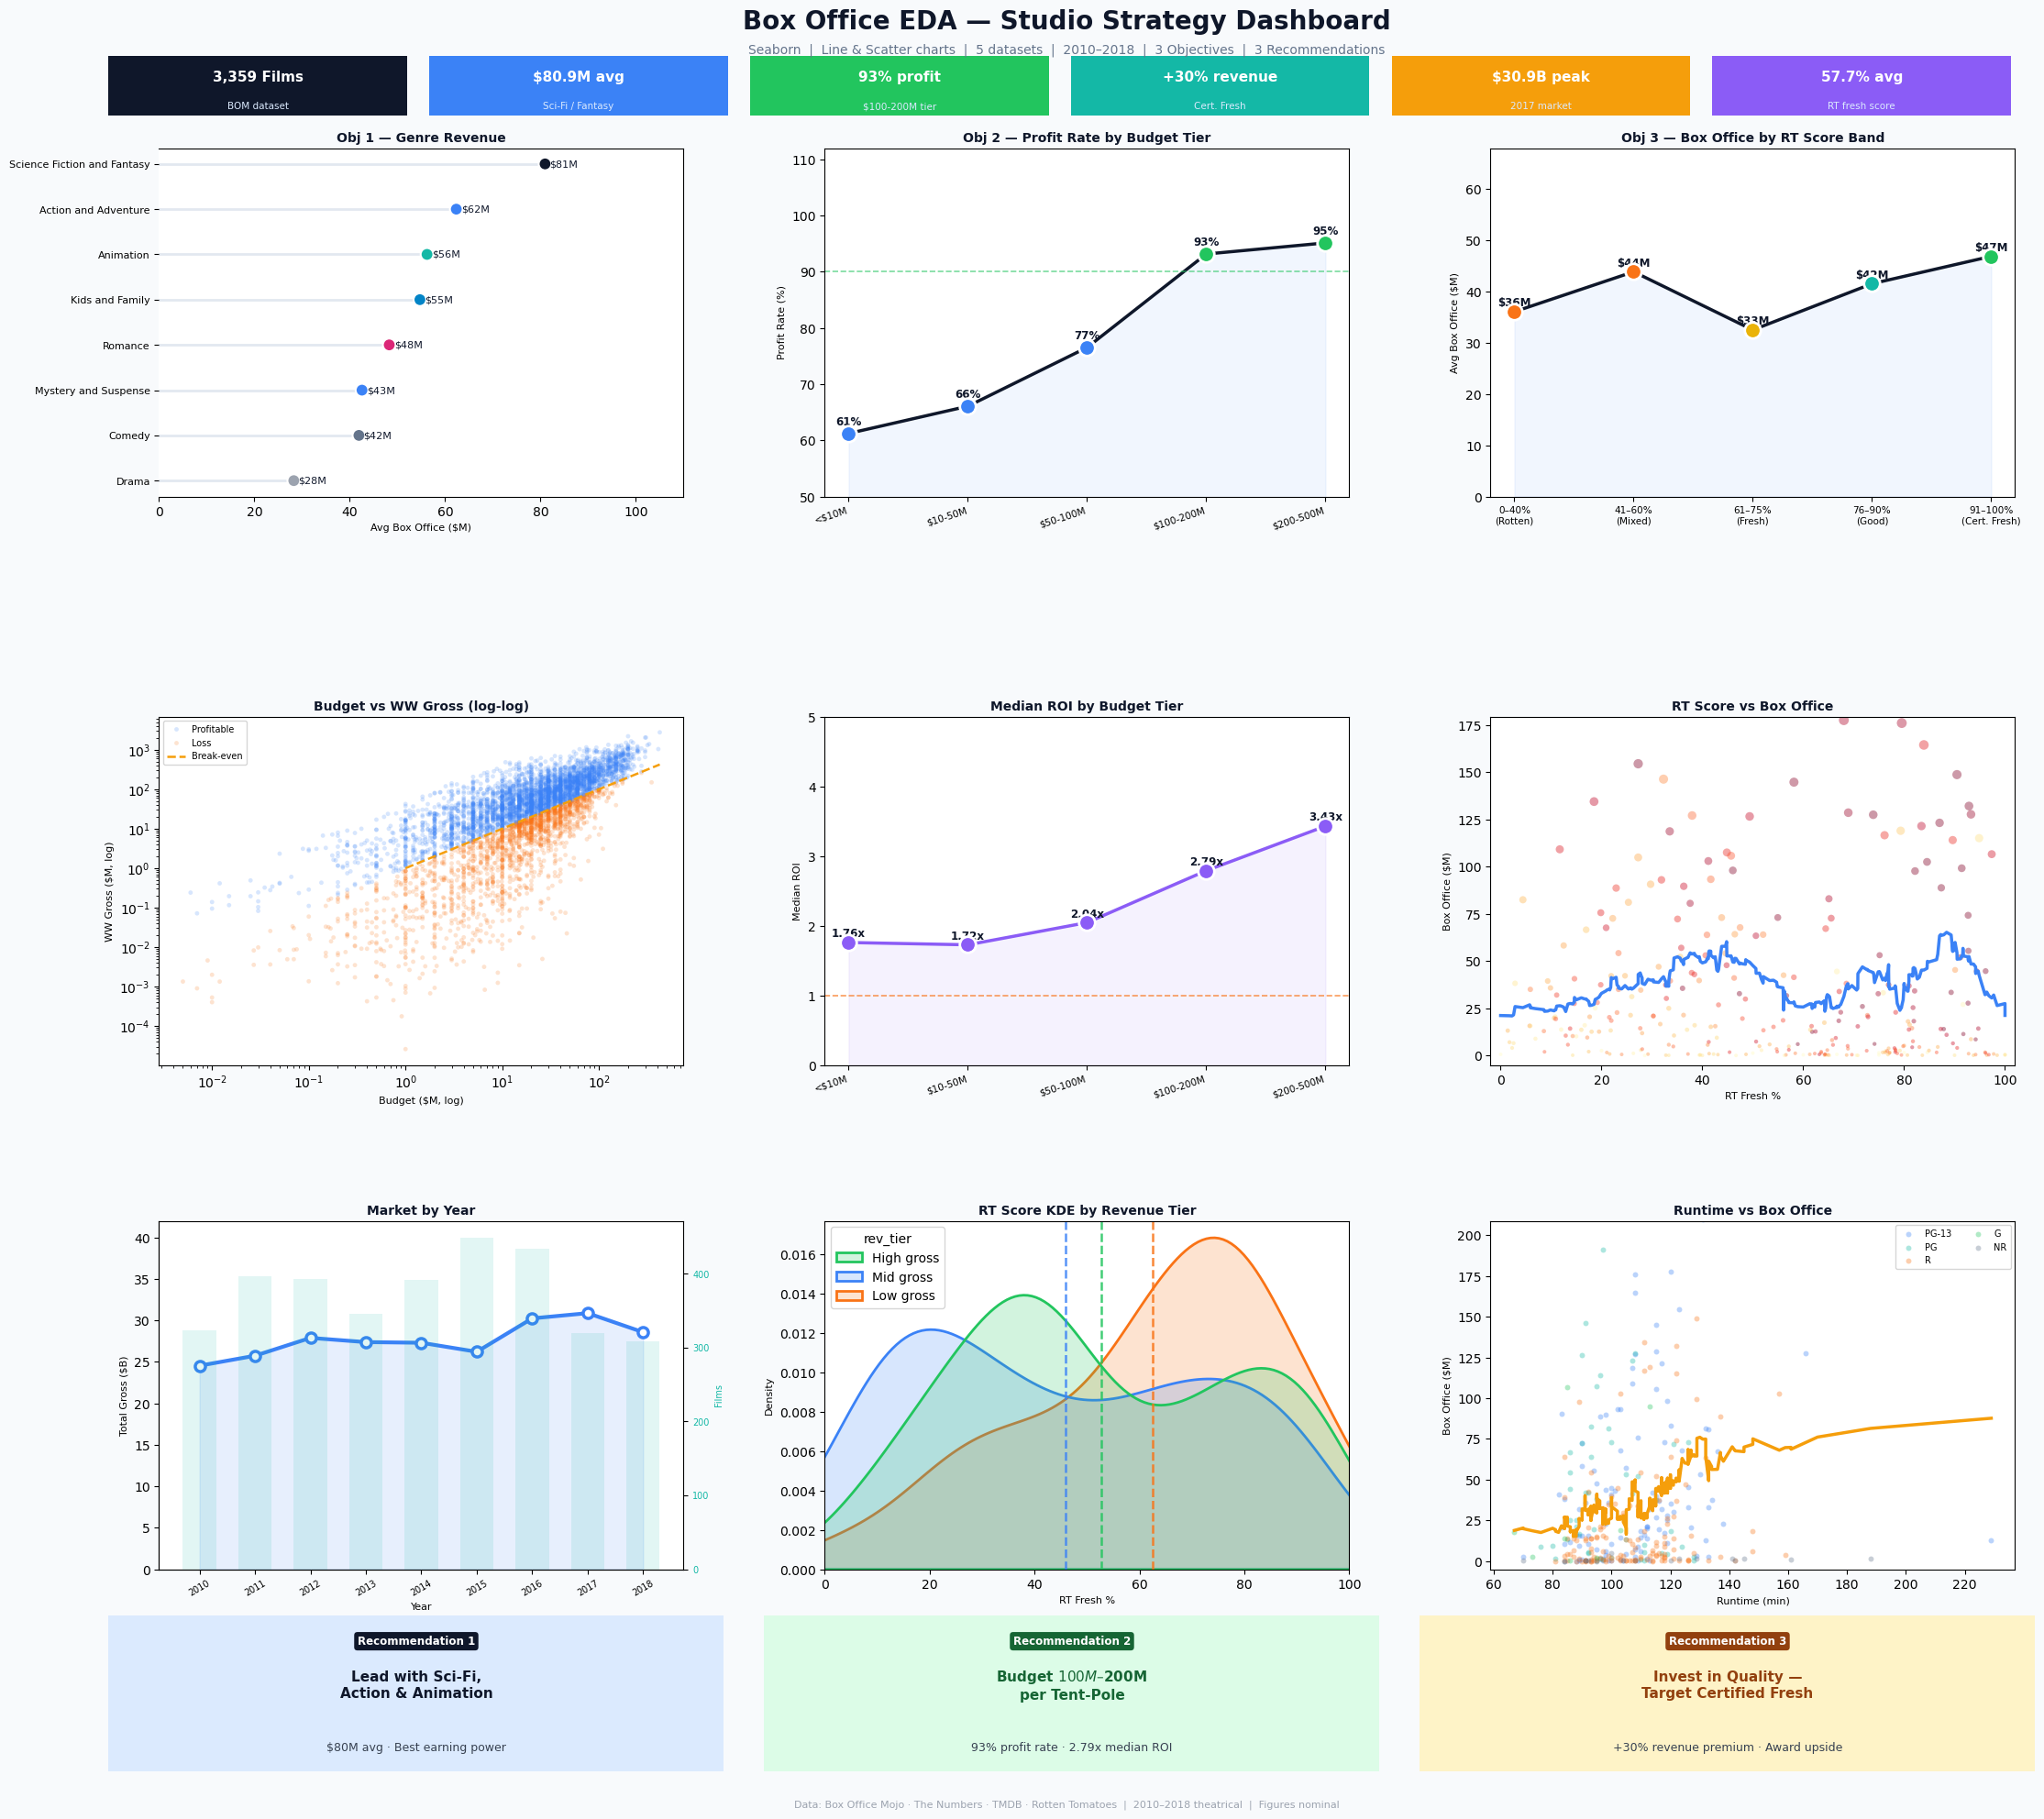

In [32]:
# Create large dashboard figure
fig = plt.figure(figsize=(22, 20), facecolor='#F8FAFC')

# Add dashboard title and subtitle
fig.text(
    0.5, 0.975, 'Box Office EDA — Studio Strategy Dashboard',
    ha='center', fontsize=20, fontweight='bold', color=NAVY
)
fig.text(
    0.5, 0.962,
    'Seaborn  |  Line & Scatter charts  |  5 datasets  |  2010–2018  |  3 Objectives  |  3 Recommendations',
    ha='center', fontsize=10, color=MGRAY
)

# ── KPI cards ──────────────────────────────────────────────────────────────
# Define headline metrics to summarize the most important findings
kpis = [
    ('3,359 Films', 'BOM dataset',        NAVY),
    ('$80.9M avg',  'Sci-Fi / Fantasy',   BLUE),
    ('93% profit',  '$100-200M tier',     GREEN),
    ('+30% revenue','Cert. Fresh',        TEAL),
    ('$30.9B peak', '2017 market',        AMBER),
    ('57.7% avg',   'RT fresh score',     PURPLE),
]

# Draw KPI cards across the top of the dashboard
for i, (val, lbl, bg) in enumerate(kpis):
    ax = fig.add_axes([0.025 + i * 0.159, 0.928, 0.148, 0.032])
    ax.set_facecolor(bg)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Main KPI value
    ax.text(
        0.5, 0.65, val,
        ha='center', va='center', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='white'
    )

    # KPI label / context
    ax.text(
        0.5, 0.15, lbl,
        ha='center', va='center', transform=ax.transAxes,
        fontsize=7.5, color='#dbeafe'
    )

# ─── Row 1: Objective summaries ────────────────────────────────────────────

# Panel A: Genre revenue
axA = fig.add_axes([0.05, 0.72, 0.26, 0.19])
axA.set_facecolor('#FFFFFF')

# Recalculate average box office in millions for display
genre_stats['avg_m2'] = genre_stats['avg_bo'] / 1e6

# Keep top 8 genres by average revenue
top8 = genre_stats.head(8)
yp = range(len(top8))

# Draw lollipop stems
for i, (_, row) in enumerate(top8.iterrows()):
    axA.plot([0, row['avg_m2']], [i, i], color='#E2E8F0', linewidth=2, zorder=1)

# Plot average box office points
axA.scatter(
    top8['avg_m2'], list(yp),
    color=[NAVY, BLUE, TEAL, '#0284C7', '#DB2777', BLUE, MGRAY, '#9CA3AF'],
    s=100, zorder=3, edgecolors='white', linewidths=1.5
)

# Label each genre with its average revenue
for i, (_, row) in enumerate(top8.iterrows()):
    axA.text(row['avg_m2'] + 1, i, f"${row['avg_m2']:.0f}M", va='center', fontsize=8, color=NAVY)

# Format axes
axA.set_yticks(list(yp))
axA.set_yticklabels(top8['genre'], fontsize=8)
axA.invert_yaxis()
axA.set_xlim(0, 110)
axA.set_xlabel('Avg Box Office ($M)', fontsize=8)
axA.spines['left'].set_visible(False)
axA.set_title('Obj 1 — Genre Revenue', fontsize=10, fontweight='bold', color=NAVY, pad=5)

# Panel B: Profit rate by budget tier
axB = fig.add_axes([0.38, 0.72, 0.26, 0.19])
axB.set_facecolor('#FFFFFF')

x = list(range(len(tier_stats)))

# Plot profit rate by tier
axB.plot(x, tier_stats['pct'], color=NAVY, linewidth=2.5)
axB.fill_between(x, tier_stats['pct'], alpha=0.07, color=BLUE)

# Add highlighted points and labels
for xi, (_, row) in enumerate(tier_stats.iterrows()):
    c = GREEN if row['pct'] >= 90 else BLUE
    axB.scatter(xi, row['pct'], s=160, color=c, zorder=4, edgecolors='white', linewidths=2)
    axB.text(xi, row['pct'] + 1.5, f"{row['pct']:.0f}%", ha='center', fontsize=8.5, fontweight='bold', color=NAVY)

# Add 90% reference line
axB.axhline(90, color=GREEN, lw=1.2, ls='--', alpha=0.6)

# Format axes
axB.set_xticks(x)
axB.set_xticklabels(tier_stats['tier'].tolist(), rotation=18, ha='right', fontsize=7.5)
axB.set_ylim(50, 112)
axB.set_ylabel('Profit Rate (%)', fontsize=8)
axB.set_title('Obj 2 — Profit Rate by Budget Tier', fontsize=10, fontweight='bold', color=NAVY, pad=5)

# Panel C: Average box office by RT score band
axC = fig.add_axes([0.71, 0.72, 0.26, 0.19])
axC.set_facecolor('#FFFFFF')

sc3 = [CORAL, '#F97316', '#EAB308', TEAL, GREEN]
x3 = list(range(len(band_stats)))

# Plot average box office across critic score bands
axC.plot(x3, band_stats['avg_bo'], color=NAVY, linewidth=2.5)
axC.fill_between(x3, band_stats['avg_bo'], alpha=0.07, color=BLUE)

# Add points and labels
for xi, (_, row) in enumerate(band_stats.iterrows()):
    axC.scatter(xi, row['avg_bo'], s=160, color=sc3[xi], zorder=4, edgecolors='white', linewidths=2)
    axC.text(xi, row['avg_bo'] + 1.1, f"${row['avg_bo']:.0f}M", ha='center', fontsize=8.5, fontweight='bold', color=NAVY)

# Format axes
axC.set_xticks(x3)
axC.set_xticklabels(band_stats['band'].astype(str).tolist(), fontsize=7.5)
axC.set_ylim(0, 68)
axC.set_ylabel('Avg Box Office ($M)', fontsize=8)
axC.set_title('Obj 3 — Box Office by RT Score Band', fontsize=10, fontweight='bold', color=NAVY, pad=5)

# ─── Row 2: Supporting diagnostics ─────────────────────────────────────────

# Panel D: Budget vs worldwide gross (log-log)
axD = fig.add_axes([0.05, 0.41, 0.26, 0.19])
axD.set_facecolor('#FFFFFF')

# Keep films with reasonable ROI range for readability
samp = tn[tn['roi'] < 50].copy()
samp['lbl'] = samp['profitable'].map({True: 'Profitable', False: 'Loss'})

sns.scatterplot(
    data=samp, x='budget_m', y='ww_m', hue='lbl',
    palette={'Profitable': BLUE, 'Loss': CORAL},
    alpha=0.2, s=12, linewidth=0, ax=axD
)

# Add break-even line
axD.plot([1, samp.budget_m.max()], [1, samp.budget_m.max()], color=AMBER, lw=1.8, ls='--', label='Break-even')

# Apply log scaling
axD.set_xscale('log')
axD.set_yscale('log')
axD.set_xlabel('Budget ($M, log)', fontsize=8)
axD.set_ylabel('WW Gross ($M, log)', fontsize=8)
axD.set_title('Budget vs WW Gross (log-log)', fontsize=10, fontweight='bold', color=NAVY, pad=5)
axD.legend(fontsize=7)

# Panel D2: Median ROI by budget tier
axD2 = fig.add_axes([0.38, 0.41, 0.26, 0.19])
axD2.set_facecolor('#FFFFFF')

axD2.plot(x, tier_stats['median_roi'], color=PURPLE, linewidth=2.5)
axD2.fill_between(x, tier_stats['median_roi'], alpha=0.08, color=PURPLE)

for xi, (_, row) in enumerate(tier_stats.iterrows()):
    axD2.scatter(xi, row['median_roi'], s=160, color=PURPLE, zorder=4, edgecolors='white', linewidths=2)
    axD2.text(xi, row['median_roi'] + 0.08, f"{row['median_roi']:.2f}x", ha='center', fontsize=8.5, fontweight='bold', color=NAVY)

# Add break-even ROI line
axD2.axhline(1, color=CORAL, lw=1.2, ls='--', alpha=0.7)

# Format axes
axD2.set_xticks(x)
axD2.set_xticklabels(tier_stats['tier'].tolist(), rotation=18, ha='right', fontsize=7.5)
axD2.set_ylim(0, 5)
axD2.set_ylabel('Median ROI', fontsize=8)
axD2.set_title('Median ROI by Budget Tier', fontsize=10, fontweight='bold', color=NAVY, pad=5)

# Panel E: RT score vs box office
axE = fig.add_axes([0.71, 0.41, 0.26, 0.19])
axE.set_facecolor('#FFFFFF')

# Scatterplot: color = review count, size = box office
sc_e = axE.scatter(
    merged['fresh_pct'], merged['bo_m'],
    c=merged['n_reviews'], cmap='YlOrRd', alpha=0.4,
    s=merged['bo_m'].clip(upper=300) * 0.3 + 8, linewidths=0,
    vmin=0, vmax=merged['n_reviews'].quantile(0.9)
)

# Add rolling average smoother
ms2 = merged.sort_values('fresh_pct').copy()
ms2['smooth'] = ms2['bo_m'].rolling(30, center=True, min_periods=10).mean()
ms2c = ms2.dropna(subset=['smooth'])
axE.plot(ms2c['fresh_pct'], ms2c['smooth'], color=BLUE, lw=2.5)

# Format axes
axE.set_xlabel('RT Fresh %', fontsize=8)
axE.set_ylabel('Box Office ($M)', fontsize=8)
axE.set_title('RT Score vs Box Office', fontsize=10, fontweight='bold', color=NAVY, pad=5)
axE.set_xlim(-2, 102)
axE.set_ylim(-5, merged['bo_m'].quantile(0.97))

# ─── Row 3: Bonus analysis ─────────────────────────────────────────────────

# Panel F: Market trend by year
axF = fig.add_axes([0.05, 0.135, 0.26, 0.19])
axF.set_facecolor('#FFFFFF')
ax_tw = axF.twinx()

# Plot total gross as line + filled area
axF.fill_between(yt['year'], yt['tot_b'], alpha=0.12, color=BLUE)
axF.plot(
    yt['year'], yt['tot_b'], color=BLUE, lw=3,
    marker='o', markersize=8, markerfacecolor='white',
    markeredgecolor=BLUE, markeredgewidth=2.5
)

# Plot film count as bars on secondary axis
ax_tw.bar(yt['year'], yt['count'], alpha=0.12, color=TEAL, width=0.6)
ax_tw.set_ylabel('Films', fontsize=7, color=TEAL)
ax_tw.tick_params(axis='y', labelcolor=TEAL, labelsize=7)
ax_tw.spines['top'].set_visible(False)
ax_tw.spines['right'].set_visible(False)

# Format axes
axF.set_xlabel('Year', fontsize=8)
axF.set_ylabel('Total Gross ($B)', fontsize=8)
axF.set_ylim(0, 42)
axF.set_xticks(yt['year'])
axF.tick_params(axis='x', rotation=30, labelsize=7)
axF.set_title('Market by Year', fontsize=10, fontweight='bold', color=NAVY, pad=5)

# Panel G: KDE of RT score by revenue tier
axG = fig.add_axes([0.38, 0.135, 0.26, 0.19])
axG.set_facecolor('#FFFFFF')

sns.kdeplot(
    data=merged, x='fresh_pct', hue='rev_tier',
    hue_order=['High gross', 'Mid gross', 'Low gross'],
    palette={'High gross': GREEN, 'Mid gross': BLUE, 'Low gross': CORAL},
    fill=True, alpha=0.2, linewidth=2, ax=axG, common_norm=False
)

# Add mean score reference lines by revenue tier
for lbl, color in [('High gross', GREEN), ('Mid gross', BLUE), ('Low gross', CORAL)]:
    m_s = merged[merged['rev_tier'] == lbl]['fresh_pct'].mean()
    axG.axvline(m_s, color=color, lw=1.8, ls='--', alpha=0.85)

# Format axes
axG.set_xlabel('RT Fresh %', fontsize=8)
axG.set_ylabel('Density', fontsize=8)
axG.set_xlim(0, 100)
axG.set_title('RT Score KDE by Revenue Tier', fontsize=10, fontweight='bold', color=NAVY, pad=5)

# Panel H: Runtime vs box office
axH = fig.add_axes([0.71, 0.135, 0.26, 0.19])
axH.set_facecolor('#FFFFFF')

# Scatter by MPAA rating
for rating, color in rc_pal.items():
    sub2 = rt_run[rt_run['rating'] == rating]
    if len(sub2):
        axH.scatter(
            sub2['runtime_min'], sub2['bo_m'],
            color=color, alpha=0.35, s=18, linewidths=0, label=rating
        )

# Add rolling average smoother
rt_s2 = rt_run.sort_values('runtime_min').copy()
rt_s2['smooth'] = rt_s2['bo_m'].rolling(25, center=True, min_periods=8).mean()
axH.plot(rt_s2['runtime_min'], rt_s2['smooth'], color=AMBER, lw=2.5)

# Format axes
axH.set_xlabel('Runtime (min)', fontsize=8)
axH.set_ylabel('Box Office ($M)', fontsize=8)
axH.set_ylim(-5, rt_run['bo_m'].quantile(0.97))
axH.legend(fontsize=7, ncol=2)
axH.set_title('Runtime vs Box Office', fontsize=10, fontweight='bold', color=NAVY, pad=5)

# ── Recommendation strip ───────────────────────────────────────────────────
# Define final business recommendations shown at the bottom
recs = [
    ('Recommendation 1', 'Lead with Sci-Fi,\nAction & Animation',
     '$80M avg · Best earning power', NAVY, '#DBEAFE'),
    ('Recommendation 2', 'Budget $100M–$200M\nper Tent-Pole',
     '93% profit rate · 2.79x median ROI', '#166534', '#DCFCE7'),
    ('Recommendation 3', 'Invest in Quality —\nTarget Certified Fresh',
     '+30% revenue premium · Award upside', '#92400E', '#FEF3C7'),
]

# Draw recommendation cards
for i, (label, title, body, fg, bg) in enumerate(recs):
    ax_r = fig.add_axes([0.025 + i * 0.325, 0.025, 0.305, 0.085])
    ax_r.set_facecolor(bg)
    for sp in ax_r.spines.values():
        sp.set_visible(False)
    ax_r.set_xticks([])
    ax_r.set_yticks([])

    # Recommendation label badge
    ax_r.text(
        0.5, 0.87, label,
        ha='center', va='top', transform=ax_r.transAxes,
        fontsize=8.5, fontweight='bold', color='white',
        bbox=dict(facecolor=fg, edgecolor='none', boxstyle='round,pad=0.3')
    )

    # Recommendation headline
    ax_r.text(
        0.5, 0.55, title,
        ha='center', va='center', transform=ax_r.transAxes,
        fontsize=11, fontweight='bold', color=fg, multialignment='center'
    )

    # Recommendation supporting evidence
    ax_r.text(
        0.5, 0.15, body,
        ha='center', va='center', transform=ax_r.transAxes,
        fontsize=9, color='#374151', multialignment='center'
    )

# Add dashboard footer
fig.text(
    0.5, 0.005,
    'Data: Box Office Mojo · The Numbers · TMDB · Rotten Tomatoes  |  2010–2018 theatrical  |  Figures nominal',
    ha='center', fontsize=8, color='#9CA3AF'
)

# Save and display final dashboard
plt.savefig('public/chart_dashboard_final.png', dpi=150, bbox_inches='tight', facecolor='#F8FAFC')
plt.show()

---
## 6. Strategic Recommendations

### Recommendation 1 — Lead with Sci-Fi, Action & Animation

| Action | Detail |
|--------|--------|
| Primary genre targets | Sci-Fi/Fantasy (\$80.9M avg), Action/Adventure (\$62.3M), Animation (\$56.2M) |
| Rating target | PG-13 for max audience breadth (\$56.5M avg vs \$23.2M for R) |
| Genres to avoid early | Drama (\$28.3M avg), Documentary (\$11.9M) |
| Secondary play | Horror micro-budget (\$1–5M) for cash flow and ROI |



### Recommendation 2 — Budget \$100M–\$200M per Tent-Pole

| Action | Detail |
|--------|--------|
| Primary budget range | \$100M–\$200M per tent-pole production |
| Expected returns | 2.79× median ROI = \$279M–\$558M worldwide on a \$100M–\$200M film |
| Micro-budget exception | \$1M–\$10M horror films for slate diversification and cash flow |
| Avoid | \$10M–\$50M range: 66% profit rate — worst risk-adjusted tier |



### Recommendation 3 — Invest in Quality — Target Certified Fresh

| Action | Detail |
|--------|--------|
| Revenue upside | +30% avg revenue for Certified Fresh vs Rotten films |
| Hire strategy | Directors with strong critical track records for first 3 films |
| Script investment | Budget \$2M–\$5M for script development before greenlight |
| Release policy | Delay release rather than cut quality — date flexibility is a competitive advantage |


---
## 7. Chart Type Selection Guide

Why each chart type was chosen over bar charts:

| Chart Type | Used For | Why Better Than Bar Chart |
|------------|----------|---------------------------|
| **Lollipop** | Genre avg vs median | Shows two values simultaneously; reduces ink; reveals skew when mean ≠ median |
| **Line + fill** | Profit rate & ROI by budget tier | Makes trend direction unmistakable; fill communicates area-under-curve |
| **Log-log scatter** | Budget vs worldwide gross | Compresses 5 orders of magnitude; reveals power-law structure invisible on linear axes |
| **Scatter + rolling avg** | RT score vs box office | Shows every data point + the underlying trend; no information hidden by aggregation |
| **Scatter + regression** | Any two continuous variables | Adds statistical trend line with R²; quantifies relationship strength |
| **KDE density** | Score distribution by revenue tier | Reveals distribution shape (bimodal, skewed) that histogram bin-size would obscure |
| **Dual-axis line+bar** | Market trend + film count | Two metrics on different scales in one chart without misleading comparisons |
| **Multi-line trend** | Studio performance over time | Each studio as its own line shows divergence and convergence over time |

> **General rule:** Use bar charts only when comparing discrete, unordered categories where bar height is the *entire* message. For ranked categories → lollipop. For trends → line. For two continuous variables → scatter. For distributions → KDE.


---
## 8. Final Summary

| Objective | Key Finding | Statistic | Recommendation |
|-----------|-------------|-----------|----------------|
| 1 — Genre Revenue | Sci-Fi/Fantasy and Action dominate per-film earnings | \$80.9M & \$62.3M avg | Lead slate with Sci-Fi, Action, Animation |
| 2 — Budget vs ROI | \$100–200M tier has the best risk-adjusted profit rate | 93.1% profit rate | Target \$100M–\$200M per tent-pole |
| 3 — Critical Quality | Certified Fresh films earn 30% more than Rotten films | +\$10.8M avg premium | Invest in quality — target Certified Fresh |
| Bonus — Market | Market grew 26%; concentrated on fewer bigger releases | \$24.5B → \$30.9B | Release 2–3 large films per year |
| Bonus — Studios | Disney earns 2× nearest rival per film | \$417M vs \$230M avg | Benchmark BV model: IP, family, quality |
| Bonus — Rating | PG-13 earns the most; R is significantly lower | \$56.5M vs \$23.2M avg | Target PG-13 for all tent-pole greenlights |

---

### Data Sources
- **Box Office Mojo** — 3,387 domestic & foreign theatrical releases, 2010–2018
- **The Numbers** — 5,782 films with production budgets and worldwide gross figures
- **Rotten Tomatoes Movie Info** — 1,560 films with MPAA rating, genre, director, box office
- **Rotten Tomatoes Reviews** — 54,432 individual critic reviews with fresh/rotten label

### Limitations
- All figures are **nominal** (not inflation-adjusted)
- Critical reception analysis uses only **299 matched films** — small sample, directional finding only
- TN production budgets **do not include P&A** (marketing) spend, which typically equals 50–100% of production budget
- Genre classification differs between RT (text) and TMDB (IDs) — both used independently

---
*Produced using Python 3 | pandas | NumPy | Seaborn | Matplotlib | SciPy*
